
# Chartmetric API — Pilotos 1 y 2

Objetivo: construir trayectorias digitales mensuales de artistas hasta **2026-03-31 inclusive**, usando sólo métricas transparentes de las plataformas originales.

## Fan Stats

Endpoint: `GET /api/artist/{id}/stat/{source}`

Se consulta **sin `field`** para inspeccionar los campos default de cada source.

Sources y variables objetivo:

- `spotify`: `followers`, `listeners`
- `twitter`: `followers`
- `youtube_channel`: `subscribers`, `views`
- `youtube_artist`: `monthly_views`
- `instagram`: `followers`
- `tiktok`: `followers`, `likes`

Son **6 requests máximos por artista**. El código pide desde una fecha deliberadamente temprana hasta `2026-03-31`; si Chartmetric dispone de menos historia, se conserva únicamente lo que devuelve.

## Playlist Evolution

Endpoint: `GET /api/playlist/by/artist/{id}/evolution`

La documentación actual lo define como una serie diaria y no documenta parámetros de fecha ni paginación. Por eso el piloto realiza **una sola llamada por artista** y luego inspecciona el rango temporal efectivamente devuelto.

Se conservan:

- Spotify: `playlist_count`, `ed_playlist_count`, `playlist_total_reach`, `ed_playlist_total_reach`
- YouTube: `playlist_count`, `ed_playlist_count`, `playlist_total_reach`, `ed_playlist_total_reach`
- Amazon: `playlist_count`, `ed_playlist_count`

## Regla central para ahorrar requests

Antes de llamar a la API, cada función verifica:

1. si la respuesta cruda ya existe en el cache local;
2. si el log registra el request como completado;
3. sólo si no existe ninguna de esas dos evidencias, llama a Chartmetric.

La respuesta cruda se guarda **antes de parsearla**. Así, si aparece un error local después de una descarga exitosa, se puede re-procesar sin repetir el request.

El archivo analítico acumulado sigue siendo uno solo: `chartmetric_raw_long.rds`. El cache crudo es un archivo técnico separado que protege las descargas ya realizadas.


In [ ]:

# PAQUETES

paquetes <- c("httr", "jsonlite", "data.table", "lubridate")

faltan <- paquetes[!paquetes %in% rownames(installed.packages())]

if (length(faltan) > 0) {
  install.packages(faltan)
}

library(httr)
library(jsonlite)
library(data.table)
library(lubridate)


## 1. Configuración

In [ ]:
# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

BASE_URL <- "https://api.chartmetric.com"

# Período definitivo para las nuevas extracciones.
FAN_SINCE <- as.Date("2021-01-01")
END_DATE <- as.Date("2026-03-31")

FAN_SOURCES <- c(
  "spotify",
  "twitter",
  "youtube_channel",
  "youtube_artist",
  "instagram",
  "tiktok"
)

TARGET_FAN_METRICS <- list(
  spotify         = c("followers", "listeners"),
  twitter         = c("followers"),
  youtube_channel = c("subscribers", "views"),
  youtube_artist  = c("monthly_views"),
  instagram       = c("followers"),
  tiktok          = c("followers", "likes")
)

TARGET_PLAYLIST_METRICS <- list(
  spotify = c(
    "playlist_count",
    "ed_playlist_count",
    "playlist_total_reach",
    "ed_playlist_total_reach"
  ),
  youtube = c(
    "playlist_count",
    "ed_playlist_count",
    "playlist_total_reach",
    "ed_playlist_total_reach"
  ),
  amazon = c(
    "playlist_count",
    "ed_playlist_count"
  )
)

OUT_DIR <- "chartmetric_pilotos"

dir.create(
  OUT_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

# ------------------------------------------------------------
# Archivos LEGACY
# Se conservan intactos.
# ------------------------------------------------------------

DATA_FILE <- file.path(
  OUT_DIR,
  "chartmetric_raw_long.rds"
)

RAW_RESPONSE_FILE <- file.path(
  OUT_DIR,
  "chartmetric_raw_responses.rds"
)

# ------------------------------------------------------------
# Log general
# ------------------------------------------------------------

LOG_FILE <- file.path(
  OUT_DIR,
  "chartmetric_request_log.csv"
)

# ------------------------------------------------------------
# Nueva arquitectura
# Un archivo por request
# ------------------------------------------------------------

RAW_REQUEST_DIR <- file.path(
  OUT_DIR,
  "raw_requests_2021_2026"
)

MONTHLY_REQUEST_DIR <- file.path(
  OUT_DIR,
  "monthly_requests_2021_2026"
)

dir.create(
  RAW_REQUEST_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

dir.create(
  MONTHLY_REQUEST_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

# Dataset mensual consolidado.
MONTHLY_FILE <- file.path(
  OUT_DIR,
  "chartmetric_monthly_2021_2026.rds"
)

cat(
  "Período:",
  format(FAN_SINCE),
  "a",
  format(END_DATE),
  "\n"
)

cat(
  "Raw legacy:",
  DATA_FILE,
  "\n"
)

cat(
  "Requests crudos nuevos:",
  RAW_REQUEST_DIR,
  "\n"
)

cat(
  "Requests mensuales nuevos:",
  MONTHLY_REQUEST_DIR,
  "\n"
)

cat(
  "Mensual consolidado:",
  MONTHLY_FILE,
  "\n"
)

## 2. Archivo maestro de artistas

In [ ]:

# ARCHIVO MAESTRO: dataset_raw_concat_7000

artist_candidates <- c(
  "dataset_raw_concat_7000.csv"
)

existing_candidates <- artist_candidates[file.exists(artist_candidates)]

ARTIST_FILE <- if (length(existing_candidates) > 0) {
  existing_candidates[1]
} else {
  NA_character_
}

load_artist_catalog <- function(path = ARTIST_FILE) {

  if (is.na(path) || !file.exists(path)) {
    message(
      "No encontré dataset_raw_concat_7000 en el working directory. ",
      "Podés definir ARTIST_FILE manualmente más adelante."
    )
    return(data.table())
  }

  x <- fread(
    path,
    select = c(
      "chartmetric_id",
      "artist_name",
      "cm_artist_rank"
    )
  )

  x[, ID := as.character(chartmetric_id)]

  x <- x[
    ,
    .(
      ID,
      artist_name,
      cm_artist_rank
    )
  ]

  unique(x, by = "ID")
}

ARTISTS <- load_artist_catalog()

if (nrow(ARTISTS) > 0) {
  cat("Artistas cargados:", nrow(ARTISTS), "\n")
  print(head(ARTISTS))
}


## 3. Autenticación

In [ ]:

# AUTENTICACIÓN
# Reutiliza el access token hasta que falte aproximadamente 1 minuto para vencer.

.cm_auth <- new.env(parent = emptyenv())
.cm_auth$token <- NULL
.cm_auth$expires_at <- as.POSIXct(NA)

get_access_token <- function(force = FALSE) {

  refresh_token <- Sys.getenv("CHARTMETRIC_REFRESH_TOKEN")

  if (refresh_token == "") {
    stop(
      "Falta CHARTMETRIC_REFRESH_TOKEN en .Renviron. ",
      "Agregalo y reiniciá el kernel de R."
    )
  }

  ahora <- Sys.time()

  vigente <- (
    !force &&
    !is.null(.cm_auth$token) &&
    !is.na(.cm_auth$expires_at) &&
    ahora < (.cm_auth$expires_at - 60)
  )

  if (vigente) {
    return(.cm_auth$token)
  }

  resp <- POST(
    paste0(BASE_URL, "/api/token"),
    body = list(refreshtoken = refresh_token),
    encode = "json",
    timeout(60)
  )

  status <- status_code(resp)
  texto <- content(resp, as = "text", encoding = "UTF-8")

  if (status != 200) {
    stop(
      "No se pudo obtener access token. HTTP ",
      status,
      "\n",
      substr(texto, 1, 1000)
    )
  }

  body <- fromJSON(
    texto,
    simplifyVector = TRUE
  )

  if (is.null(body$token) || is.null(body$expires_in)) {
    stop("La respuesta de autenticación no tiene la estructura esperada.")
  }

  .cm_auth$token <- body$token
  .cm_auth$expires_at <- ahora + as.numeric(body$expires_in)

  cat(
    "Autenticación OK. Access token obtenido; no se muestra.\n"
  )

  invisible(.cm_auth$token)
}


In [ ]:

# PRUEBA DE VIGENCIA DE LA CUENTA/API
# No descarga datos de artistas.

get_access_token(force = TRUE)


## 4. Helpers, persistencia, cache y log

In [ ]:

# HELPERS BÁSICOS

scalar_chr <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA_character_)
  }

  as.character(
    unlist(
      x,
      recursive = TRUE,
      use.names = FALSE
    )[1]
  )
}

scalar_num <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA_real_)
  }

  suppressWarnings(
    as.numeric(
      unlist(
        x,
        recursive = TRUE,
        use.names = FALSE
      )[1]
    )
  )
}

scalar_lgl <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA)
  }

  suppressWarnings(
    as.logical(
      unlist(
        x,
        recursive = TRUE,
        use.names = FALSE
      )[1]
    )
  )
}

# Chartmetric puede devolver tanto "YYYY-MM-DD" como timestamps ISO con milisegundos.
parse_timestamp <- function(x) {

  x <- as.character(x)

  suppressWarnings(
    as.POSIXct(
      x,
      tz = "UTC",
      tryFormats = c(
        "%Y-%m-%dT%H:%M:%OSZ",
        "%Y-%m-%dT%H:%M:%OS",
        "%Y-%m-%d %H:%M:%OS",
        "%Y-%m-%d"
      )
    )
  )
}

safe_min_date <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  format(min(x))
}

safe_max_date <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  format(max(x))
}


In [ ]:
# ============================================================
# CACHE DE RESPUESTAS CRUDAS
# UN ARCHIVO INDEPENDIENTE POR REQUEST
# ============================================================

request_file_name <- function(request_key) {

  safe_name <- gsub(
    "|",
    "__",
    as.character(request_key),
    fixed = TRUE
  )

  paste0(
    safe_name,
    ".rds"
  )
}


raw_response_path <- function(request_key) {

  file.path(
    RAW_REQUEST_DIR,
    request_file_name(request_key)
  )
}


monthly_response_path <- function(request_key) {

  file.path(
    MONTHLY_REQUEST_DIR,
    request_file_name(request_key)
  )
}


raw_response_exists <- function(request_key) {

  file.exists(
    raw_response_path(request_key)
  )
}


monthly_response_exists <- function(request_key) {

  file.exists(
    monthly_response_path(request_key)
  )
}


get_raw_response <- function(request_key) {

  path <- raw_response_path(
    request_key
  )

  if (!file.exists(path)) {
    return(NULL)
  }

  safe_read_rds(
    path,
    default = NULL
  )
}


save_raw_response <- function(
  request_key,
  body
) {

  path <- raw_response_path(
    request_key
  )

  if (file.exists(path)) {
    return(invisible(NULL))
  }

  safe_save_rds(
    body,
    path
  )

  invisible(NULL)
}


save_monthly_response <- function(
  request_key,
  monthly
) {

  safe_save_rds(
    monthly,
    monthly_response_path(request_key)
  )

  invisible(NULL)
}

In [ ]:
# ============================================================
# LECTURA Y GUARDADO SEGURO DE ARCHIVOS RDS
# Versión robusta para Windows
# ============================================================


safe_read_rds <- function(path, default = NULL) {

  backup <- paste0(path, ".bak")

  if (!file.exists(path)) {

    if (file.exists(backup)) {

      ok <- file.copy(
        backup,
        path,
        overwrite = TRUE
      )

      if (!ok) {
        stop(
          "No se pudo recuperar el backup de: ",
          path
        )
      }

    } else {

      return(default)
    }
  }


  tryCatch(

    readRDS(path),

    error = function(e) {

      if (!file.exists(backup)) {
        stop(conditionMessage(e))
      }

      ok <- file.copy(
        backup,
        path,
        overwrite = TRUE
      )

      if (!ok) {
        stop(
          "No se pudo recuperar el backup de: ",
          path
        )
      }

      readRDS(path)
    }
  )
}


safe_save_rds <- function(object, path) {

  dir.create(
    dirname(path),
    recursive = TRUE,
    showWarnings = FALSE
  )

  tmp <- paste0(
    path,
    ".tmp"
  )

  backup <- paste0(
    path,
    ".bak"
  )


  # Limpiar temporal viejo.
  if (file.exists(tmp)) {
    unlink(tmp)
  }


  # ----------------------------------------------------------
  # 1. Escribir primero el temporal
  # ----------------------------------------------------------

  saveRDS(
    object,
    tmp
  )


  # ----------------------------------------------------------
  # 2. Verificar el temporal
  # ----------------------------------------------------------

  valid_tmp <- tryCatch(
    {
      readRDS(tmp)
      TRUE
    },
    error = function(e) FALSE
  )


  if (!valid_tmp) {

    unlink(tmp)

    stop(
      "El archivo temporal RDS quedó inválido."
    )
  }


  # ----------------------------------------------------------
  # 3. Crear backup si ya existe archivo definitivo
  # ----------------------------------------------------------

  if (file.exists(backup)) {
    unlink(backup)
  }


  if (file.exists(path)) {

    ok_backup <- file.copy(
      path,
      backup,
      overwrite = TRUE
    )

    if (!ok_backup) {

      unlink(tmp)

      stop(
        "No se pudo crear el backup. ",
        "El archivo original no fue modificado."
      )
    }
  }


  # ----------------------------------------------------------
  # 4. Copiar temporal al archivo definitivo
  # ----------------------------------------------------------

  ok_save <- file.copy(
    tmp,
    path,
    overwrite = TRUE
  )


  if (!ok_save) {

    unlink(tmp)

    stop(
      "No se pudo guardar el nuevo archivo RDS."
    )
  }


  unlink(tmp)


  # ----------------------------------------------------------
  # 5. Verificación final
  # ----------------------------------------------------------

  valid_final <- tryCatch(
    {
      readRDS(path)
      TRUE
    },
    error = function(e) FALSE
  )


  if (!valid_final) {

    if (file.exists(backup)) {

      file.copy(
        backup,
        path,
        overwrite = TRUE
      )
    }

    stop(
      "El nuevo RDS quedó inválido. ",
      "Se restauró la versión anterior."
    )
  }


  # ----------------------------------------------------------
  # 6. Todo salió bien
  # ----------------------------------------------------------

  if (file.exists(backup)) {
    unlink(backup)
  }


  invisible(NULL)
}

In [ ]:
# ============================================================
# ARCHIVO LONG ACUMULADO
# ============================================================

load_raw_data <- function() {

  x <- safe_read_rds(
    DATA_FILE,
    default = data.table()
  )

  as.data.table(x)
}


append_raw_data <- function(new_data) {

  if (
    is.null(new_data) ||
    nrow(new_data) == 0
  ) {
    return(invisible(NULL))
  }

  old <- load_raw_data()

  all <- rbindlist(
    list(
      old,
      as.data.table(new_data)
    ),
    fill = TRUE,
    use.names = TRUE
  )

  dedup_cols <- intersect(
    c(
      "artist_id",
      "endpoint",
      "source",
      "metric",
      "timestamp"
    ),
    names(all)
  )

  if (length(dedup_cols) > 0) {

    all <- unique(
      all,
      by = dedup_cols,
      fromLast = TRUE
    )
  }

  safe_save_rds(
    all,
    DATA_FILE
  )

  invisible(NULL)
}

In [ ]:
# ============================================================
# LOG
# Escritura incremental
# ============================================================

LOG_COLUMNS <- c(
  "request_key",
  "artist_id",
  "endpoint",
  "source",
  "requested_since",
  "requested_until",
  "status_code",
  "ok",
  "returned_fields",
  "n_rows",
  "min_date",
  "max_date",
  "rate_limit_limit",
  "rate_limit_remaining",
  "rate_limit_reset",
  "completed_at",
  "note"
)


empty_request_log <- function() {

  as.data.table(
    setNames(
      replicate(
        length(LOG_COLUMNS),
        character(),
        simplify = FALSE
      ),
      LOG_COLUMNS
    )
  )
}


read_request_log <- function() {

  if (!file.exists(LOG_FILE)) {
    return(
      empty_request_log()
    )
  }

  x <- fread(
    LOG_FILE,
    colClasses = "character",
    na.strings = NULL
  )

  for (
    col in setdiff(
      LOG_COLUMNS,
      names(x)
    )
  ) {

    x[
      ,
      (col) := NA_character_
    ]
  }

  setcolorder(
    x,
    LOG_COLUMNS
  )

  # Si un request fue registrado más de una vez,
  # conservar el registro más reciente.
  x <- x[
    !duplicated(
      request_key,
      fromLast = TRUE
    )
  ]

  x
}


write_log_row <- function(row) {

  row <- as.data.table(
    row
  )

  for (
    col in setdiff(
      LOG_COLUMNS,
      names(row)
    )
  ) {

    row[
      ,
      (col) := NA_character_
    ]
  }

  row <- row[
    ,
    ..LOG_COLUMNS
  ]

  for (col in LOG_COLUMNS) {

    row[
      ,
      (col) := as.character(
        get(col)
      )
    ]
  }

  log_exists <-
    file.exists(LOG_FILE) &&
    file.info(LOG_FILE)$size > 0

  fwrite(
    row,
    LOG_FILE,
    append = log_exists,
    col.names = !log_exists,
    na = ""
  )

  invisible(NULL)
}

request_completed <- function(request_key) {

  x <- read_request_log()

  if (nrow(x) == 0) {
    return(FALSE)
  }

  key_value <- as.character(
    request_key
  )

  rows <- x[
    request_key == key_value
  ]

  if (nrow(rows) == 0) {
    return(FALSE)
  }

  any(
    toupper(rows$ok) == "TRUE",
    na.rm = TRUE
  )
}




## 5. Request keys e inventario de requests

In [ ]:
# ============================================================
# REQUEST KEYS Y CONTROL DE PERÍODO
# ============================================================


fan_request_key <- function(
  artist_id,
  source
) {

  paste(
    "fan_stats",
    as.character(artist_id),
    source,
    format(
      FAN_SINCE,
      "%Y-%m-%d"
    ),
    format(
      END_DATE,
      "%Y-%m-%d"
    ),
    "field_default",
    sep = "|"
  )
}


playlist_request_key <- function(
  artist_id
) {

  paste(
    "playlist_evolution",
    as.character(artist_id),
    format(
      FAN_SINCE,
      "%Y-%m-%d"
    ),
    format(
      END_DATE,
      "%Y-%m-%d"
    ),
    "historical_v2",
    sep = "|"
  )
}


fan_completed_for_period <- function(
  log,
  artist_id_value,
  source_value
) {

  if (nrow(log) == 0) {
    return(FALSE)
  }

  rows <- log[
    endpoint == "fan_stats" &
      artist_id == as.character(
        artist_id_value
      ) &
      source == source_value &
      toupper(ok) == "TRUE"
  ]

  if (nrow(rows) == 0) {
    return(FALSE)
  }

  since_dates <- suppressWarnings(
    as.Date(
      rows$requested_since
    )
  )

  until_dates <- suppressWarnings(
    as.Date(
      rows$requested_until
    )
  )

  any(
    !is.na(since_dates) &
      !is.na(until_dates) &
      since_dates <= FAN_SINCE &
      until_dates >= END_DATE
  )
}


fan_needs_api <- function(
  log,
  artist_id,
  source
) {

  if (
    fan_completed_for_period(
      log,
      artist_id,
      source
    )
  ) {

    return(FALSE)
  }

  key <- fan_request_key(
    artist_id,
    source
  )

  if (
    raw_response_exists(
      key
    )
  ) {

    return(FALSE)
  }

  TRUE
}


request_needs_api <- function(
  request_key
) {

  if (
    raw_response_exists(
      request_key
    )
  ) {

    return(FALSE)
  }

  if (
    request_completed(
      request_key
    )
  ) {

    return(FALSE)
  }

  TRUE
}

## 6. GET genérico

In [ ]:
# ============================================================
# GET GENÉRICO
#
# Mantiene exactamente el contrato:
#   ok, status, body, text, headers
#
# 401:
#   renueva el access token una vez.
#
# 429:
#   - espera sólo si el reset es corto;
#   - si la espera supera 10 segundos, NO bloquea el kernel;
#   - la extracción se pausa y podrá retomarse después.
# ============================================================


MAX_SHORT_RATE_LIMIT_WAIT <- 20


header_value <- function(h, name) {

  if (
    is.null(h) ||
    length(h) == 0
  ) {
    return(NA_character_)
  }

  nms <- tolower(
    names(h)
  )

  pos <- which(
    nms == tolower(name)
  )

  if (length(pos) == 0) {
    return(NA_character_)
  }

  as.character(
    h[[pos[1]]]
  )
}


rate_limit_wait <- function(
  h,
  fallback_seconds = 1,
  safety_seconds = 0.25
) {

  reset_value <- suppressWarnings(
    as.numeric(
      header_value(
        h,
        "x-ratelimit-reset"
      )
    )
  )

  if (
    !is.na(reset_value) &&
    is.finite(reset_value)
  ) {

    wait_seconds <-
      reset_value -
      as.numeric(Sys.time()) +
      safety_seconds

    return(
      max(
        wait_seconds,
        safety_seconds
      )
    )
  }

  fallback_seconds
}


rate_limit_reset_at <- function(h) {

  reset_value <- suppressWarnings(
    as.numeric(
      header_value(
        h,
        "x-ratelimit-reset"
      )
    )
  )

  if (
    is.na(reset_value) ||
    !is.finite(reset_value)
  ) {

    return(
      NA_character_
    )
  }

  format(
    as.POSIXct(
      reset_value,
      origin = "1970-01-01",
      tz = "UTC"
    ),
    "%Y-%m-%d %H:%M:%S UTC"
  )
}


cm_get <- function(
  path,
  query = list(),
  max_429_retries = 3L,
  max_short_wait_seconds =
    MAX_SHORT_RATE_LIMIT_WAIT
) {

  token <- get_access_token()


  do_get <- function(tok) {

    tryCatch(
      GET(
        paste0(
          BASE_URL,
          path
        ),
        add_headers(
          Authorization = paste(
            "Bearer",
            tok
          )
        ),
        query = query,
        timeout(90)
      ),
      error = function(e) e
    )
  }


  refreshed_401 <- FALSE
  retry_429 <- 0L


  repeat {

    resp <- do_get(
      token
    )


    # --------------------------------------------------------
    # Error local o de conexión
    # --------------------------------------------------------

    if (
      inherits(
        resp,
        "error"
      )
    ) {

      return(
        list(
          ok = FALSE,
          status = NA_integer_,
          body = NULL,
          text = conditionMessage(resp),
          headers = list()
        )
      )
    }


    status <- status_code(
      resp
    )

    h <- headers(
      resp
    )


    # --------------------------------------------------------
    # 401: renovar token una única vez
    # --------------------------------------------------------

    if (
      status == 401 &&
      !refreshed_401
    ) {

      cat(
        "  401 - renovando access token...\n"
      )

      token <- get_access_token(
        force = TRUE
      )

      refreshed_401 <- TRUE

      next
    }


    # --------------------------------------------------------
    # 429
    # --------------------------------------------------------

    if (status == 429) {

      retry_429 <-
        retry_429 + 1L

      fallback_seconds <- min(
        2 ^ (retry_429 - 1),
        30
      )

      wait_seconds <- rate_limit_wait(
        h,
        fallback_seconds =
          fallback_seconds,
        safety_seconds = 0.25
      )

      reset_at <- rate_limit_reset_at(
        h
      )


      # Espera demasiado larga:
      # NO dejar el kernel bloqueado.
      if (
        wait_seconds >
          max_short_wait_seconds
      ) {

        stop(
          paste0(
            "RATE_LIMIT_LARGO: Chartmetric devolvió 429. ",
            "Indica esperar aproximadamente ",
            round(wait_seconds),
            " segundos. Reset informado: ",
            reset_at,
            "."
          ),
          call. = FALSE
        )
      }


      # Demasiados 429 consecutivos,
      # aunque sean de ventana corta.
      if (
        retry_429 >
          max_429_retries
      ) {

        stop(
          paste0(
            "RATE_LIMIT_REPETIDO: ",
            "se alcanzó el máximo de reintentos 429."
          ),
          call. = FALSE
        )
      }


      cat(
        "  429 corto - esperando ",
        round(
          wait_seconds,
          2
        ),
        " segundos. Reintento ",
        retry_429,
        "/",
        max_429_retries,
        "\n",
        sep = ""
      )

      flush.console()

      Sys.sleep(
        wait_seconds
      )

      next
    }


    # --------------------------------------------------------
    # Respuesta final
    # --------------------------------------------------------

    texto <- content(
      resp,
      as = "text",
      encoding = "UTF-8"
    )


    body <- tryCatch(
      fromJSON(
        texto,
        simplifyVector = FALSE
      ),
      error = function(e) NULL
    )


    return(
      list(
        ok =
          status >= 200 &&
          status < 300,

        status =
          status,

        body =
          body,

        text =
          texto,

        headers =
          h
      )
    )
  }
}

## 7. Fan Stats

In [ ]:
parse_fan_stats <- function(
  body,
  artist_id,
  source
) {

  if (
    is.null(body) ||
    is.null(body$obj)
  ) {

    return(
      data.table()
    )
  }


  obj <- body$obj


  metrics <- TARGET_FAN_METRICS[[source]]


  if (
    is.null(metrics) ||
    length(metrics) == 0
  ) {

    return(
      data.table()
    )
  }


  metrics <- intersect(
    metrics,
    names(obj)
  )


  if (length(metrics) == 0) {

    return(
      data.table()
    )
  }


  resultado <- list()


  for (metric in metrics) {

    pts <- obj[[metric]]


    if (
      is.null(pts) ||
      length(pts) == 0
    ) {

      next
    }


    # Si viene un único punto como objeto,
    # transformarlo en lista de un punto.
    if (
      is.list(pts) &&
      (
        "timestp" %in% names(pts) ||
        "value" %in% names(pts)
      )
    ) {

      pts <- list(
        pts
      )
    }


    if (!is.list(pts)) {
      next
    }


    filas <- lapply(
      pts,
      function(p) {

        if (!is.list(p)) {
          return(NULL)
        }


        if (
          !(
            "timestp" %in%
              names(p)
          )
        ) {

          return(NULL)
        }


        data.table(
          artist_id =
            as.character(
              artist_id
            ),

          endpoint =
            "fan_stats",

          source =
            source,

          metric =
            metric,

          timestamp =
            scalar_chr(
              p$timestp
            ),

          value =
            scalar_num(
              p$value
            ),

          interpolated =
            scalar_lgl(
              p$is_interpolated
            ),

          extrapolated =
            scalar_lgl(
              p$is_extrapolated
            ),

          flags =
            scalar_chr(
              p$flags
            )
        )
      }
    )


    filas <- Filter(
      Negate(is.null),
      filas
    )


    if (
      length(filas) > 0
    ) {

      resultado[[metric]] <- rbindlist(
        filas,
        fill = TRUE
      )
    }
  }


  if (
    length(resultado) == 0
  ) {

    return(
      data.table()
    )
  }


  rbindlist(
    resultado,
    fill = TRUE
  )
}

In [ ]:
# ============================================================
# FAN STATS
# PROCESAMIENTO MENSUAL + EXTRACCIÓN
# ============================================================

fan_raw_to_monthly <- function(raw) {

  if (
    is.null(raw) ||
    nrow(raw) == 0
  ) {

    return(
      data.table()
    )
  }

  d <- copy(
    as.data.table(raw)
  )

  d[
    ,
    timestamp_dt :=
      parse_timestamp(
        timestamp
      )
  ]

  d[
    ,
    observed_date :=
      as.Date(
        timestamp_dt
      )
  ]

  d <- d[
    !is.na(observed_date) &
      observed_date >= FAN_SINCE &
      observed_date <= END_DATE
  ]

  if (nrow(d) == 0) {

    return(
      data.table()
    )
  }

  d[
    ,
    variable := paste(
      endpoint,
      source,
      metric,
      sep = "__"
    )
  ]

  d[
    ,
    month := as.Date(
      format(
        observed_date,
        "%Y-%m-01"
      )
    )
  ]

  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    month,
    timestamp_dt
  )

  monthly <- d[
    ,
    .SD[.N],
    by = .(
      artist_id,
      endpoint,
      source,
      metric,
      variable,
      month
    )
  ]

  monthly[
    ,
    .(
      artist_id,
      month,
      endpoint,
      source,
      metric,
      variable,
      observed_date,
      value,
      interpolated,
      extrapolated,
      flags
    )
  ]
}


process_fan_body <- function(
  body,
  artist_id,
  source,
  status_code_value = 200L,
  response_headers = list(),
  note = ""
) {

  request_key <- fan_request_key(
    artist_id,
    source
  )

  fields <- if (
    !is.null(body) &&
      !is.null(body$obj)
  ) {

    names(
      body$obj
    )

  } else {

    character()
  }

  raw <- parse_fan_stats(
    body,
    artist_id,
    source
  )

  monthly <- fan_raw_to_monthly(
    raw
  )

  # Guardar el derivado mensual de ESTE request.
  # No se toca el raw_long acumulado.
  save_monthly_response(
    request_key,
    monthly
  )

  fechas <- if (
    nrow(raw) > 0
  ) {

    as.Date(
      parse_timestamp(
        raw$timestamp
      )
    )

  } else {

    as.Date(
      character()
    )
  }

  write_log_row(
    data.table(
      request_key =
        request_key,

      artist_id =
        as.character(
          artist_id
        ),

      endpoint =
        "fan_stats",

      source =
        source,

      requested_since =
        format(
          FAN_SINCE
        ),

      requested_until =
        format(
          END_DATE
        ),

      status_code =
        as.character(
          status_code_value
        ),

      ok =
        "TRUE",

      returned_fields =
        paste(
          fields,
          collapse = ";"
        ),

      n_rows =
        as.character(
          nrow(raw)
        ),

      min_date =
        safe_min_date(
          fechas
        ),

      max_date =
        safe_max_date(
          fechas
        ),

      rate_limit_limit =
        header_value(
          response_headers,
          "x-ratelimit-limit"
        ),

      rate_limit_remaining =
        header_value(
          response_headers,
          "x-ratelimit-remaining"
        ),

      rate_limit_reset =
        header_value(
          response_headers,
          "x-ratelimit-reset"
        ),

      completed_at =
        format(
          Sys.time(),
          "%Y-%m-%d %H:%M:%S"
        ),

      note =
        note
    )
  )

  cat(
    "  Filas objetivo parseadas:",
    nrow(raw),
    "\n"
  )

  cat(
    "  Filas mensuales guardadas:",
    nrow(monthly),
    "\n"
  )

  invisible(
    monthly
  )
}


extract_fan_source <- function(
  artist_id,
  source,
  log_snapshot = NULL
) {

  artist_id <- as.character(
    artist_id
  )

  if (
    !(source %in% FAN_SOURCES)
  ) {

    stop(
      "Source no previsto: ",
      source
    )
  }

  if (is.null(log_snapshot)) {

    log_snapshot <-
      read_request_log()
  }

  request_key <- fan_request_key(
    artist_id,
    source
  )

  # ----------------------------------------------------------
  # 1. Ya existe un request que cubre todo el período.
  # ----------------------------------------------------------

  if (
    fan_completed_for_period(
      log_snapshot,
      artist_id,
      source
    )
  ) {

    # Caso excepcional:
    # existe el raw nuevo pero falta su derivado mensual.
    if (
      raw_response_exists(
        request_key
      ) &&
      !monthly_response_exists(
        request_key
      )
    ) {

      cat(
        "CACHE:",
        source,
        "- reconstruyendo mensual\n"
      )

      body <- get_raw_response(
        request_key
      )

      return(
        process_fan_body(
          body = body,
          artist_id = artist_id,
          source = source,
          status_code_value = 200L,
          response_headers = list(),
          note = "Reconstruido desde cache crudo"
        )
      )
    }

    cat(
      "SKIP:",
      source,
      "- período ya cubierto\n"
    )

    return(
      invisible(NULL)
    )
  }

  # ----------------------------------------------------------
  # 2. Existe respuesta cruda nueva pero faltó procesarla.
  # ----------------------------------------------------------

  if (
    raw_response_exists(
      request_key
    )
  ) {

    cat(
      "CACHE:",
      source,
      "- artista",
      artist_id,
      "\n"
    )

    body <- get_raw_response(
      request_key
    )

    return(
      process_fan_body(
        body = body,
        artist_id = artist_id,
        source = source,
        status_code_value = 200L,
        response_headers = list(),
        note = "Procesado desde cache crudo local"
      )
    )
  }

  # ----------------------------------------------------------
  # 3. Recién acá llamar a Chartmetric.
  # ----------------------------------------------------------

  cat(
    "REQUEST:",
    source,
    "- artista",
    artist_id,
    "\n"
  )

  resp <- cm_get(
    path = paste0(
      "/api/artist/",
      artist_id,
      "/stat/",
      source
    ),
    query = list(
      since =
        format(
          FAN_SINCE
        ),

      until =
        format(
          END_DATE
        )
    )
  )

  if (!resp$ok) {

    write_log_row(
      data.table(
        request_key =
          request_key,

        artist_id =
          artist_id,

        endpoint =
          "fan_stats",

        source =
          source,

        requested_since =
          format(
            FAN_SINCE
          ),

        requested_until =
          format(
            END_DATE
          ),

        status_code =
          as.character(
            resp$status
          ),

        ok =
          "FALSE",

        returned_fields =
          NA_character_,

        n_rows =
          "0",

        min_date =
          NA_character_,

        max_date =
          NA_character_,

        rate_limit_limit =
          header_value(
            resp$headers,
            "x-ratelimit-limit"
          ),

        rate_limit_remaining =
          header_value(
            resp$headers,
            "x-ratelimit-remaining"
          ),

        rate_limit_reset =
          header_value(
            resp$headers,
            "x-ratelimit-reset"
          ),

        completed_at =
          format(
            Sys.time(),
            "%Y-%m-%d %H:%M:%S"
          ),

        note =
          substr(
            resp$text,
            1,
            1000
          )
      )
    )

    cat(
      "  ERROR HTTP:",
      ifelse(
        is.na(resp$status),
        "sin status",
        resp$status
      ),
      "\n"
    )

    return(
      invisible(NULL)
    )
  }

  # Primero preservar la respuesta original.
  save_raw_response(
    request_key,
    resp$body
  )

  # Después procesarla.
  process_fan_body(
    body = resp$body,
    artist_id = artist_id,
    source = source,
    status_code_value = resp$status,
    response_headers = resp$headers,
    note = "Descargado desde API"
  )
}

## 8. Playlist Evolution

In [ ]:
parse_playlist_evolution <- function(body, artist_id) {

  if (
    is.null(body) ||
    is.null(body$obj)
  ) {
    return(data.table())
  }

  resultado <- list()

  for (
    platform in names(TARGET_PLAYLIST_METRICS)
  ) {

    regs <- body$obj[[platform]]

    if (
      is.null(regs) ||
      length(regs) == 0 ||
      !is.list(regs)
    ) {
      next
    }

    metrics <- TARGET_PLAYLIST_METRICS[[platform]]
    filas_platform <- list()

    for (i in seq_along(regs)) {

      r <- regs[[i]]

      if (!is.list(r)) {
        next
      }

      if (!("created_at" %in% names(r))) {
        next
      }

      filas_metricas <- lapply(
        metrics,
        function(metric) {

          data.table(
            artist_id = as.character(artist_id),
            endpoint = "playlist_evolution",
            source = platform,
            metric = metric,
            timestamp = scalar_chr(r$created_at),
            value = scalar_num(r[[metric]]),
            interpolated = NA,
            extrapolated = NA,
            flags = NA_character_
          )
        }
      )

      filas_platform[[i]] <- rbindlist(
        filas_metricas,
        fill = TRUE
      )
    }

    filas_platform <- Filter(
      Negate(is.null),
      filas_platform
    )

    if (length(filas_platform) > 0) {
      resultado[[platform]] <- rbindlist(
        filas_platform,
        fill = TRUE
      )
    }
  }

  if (length(resultado) == 0) {
    return(data.table())
  }

  rbindlist(
    resultado,
    fill = TRUE
  )
}

In [ ]:
# ============================================================
# PLAYLIST EVOLUTION
# PROCESAMIENTO + EXTRACCIÓN
# Arquitectura individual por request
# Período explícito: FAN_SINCE a END_DATE
# ============================================================


playlist_raw_to_monthly <- function(raw) {

  if (
    is.null(raw) ||
    nrow(raw) == 0
  ) {
    return(
      data.table()
    )
  }


  d <- copy(
    as.data.table(raw)
  )


  d[
    ,
    timestamp_dt :=
      parse_timestamp(
        timestamp
      )
  ]


  d[
    ,
    observed_date :=
      as.Date(
        timestamp_dt
      )
  ]


  d <- d[
    !is.na(observed_date) &
      observed_date >= FAN_SINCE &
      observed_date <= END_DATE
  ]


  if (
    nrow(d) == 0
  ) {
    return(
      data.table()
    )
  }


  d[
    ,
    variable := paste(
      endpoint,
      source,
      metric,
      sep = "__"
    )
  ]


  d[
    ,
    month := as.Date(
      format(
        observed_date,
        "%Y-%m-01"
      )
    )
  ]


  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    month,
    timestamp_dt
  )


  # Última observación disponible de cada mes.

  monthly <- d[
    ,
    .SD[.N],
    by = .(
      artist_id,
      endpoint,
      source,
      metric,
      variable,
      month
    )
  ]


  monthly[
    ,
    .(
      artist_id,
      month,
      endpoint,
      source,
      metric,
      variable,
      observed_date,
      value,
      interpolated,
      extrapolated,
      flags
    )
  ]
}


process_playlist_body <- function(
  body,
  artist_id,
  status_code_value = 200L,
  response_headers = list(),
  note = ""
) {

  request_key <- playlist_request_key(
    artist_id
  )


  platforms <- if (
    !is.null(body) &&
      !is.null(body$obj)
  ) {

    names(
      body$obj
    )

  } else {

    character()
  }


  raw <- parse_playlist_evolution(
    body,
    artist_id
  )


  monthly <- playlist_raw_to_monthly(
    raw
  )


  # Guardar el monthly antes de registrar
  # el request como completado.

  save_monthly_response(
    request_key,
    monthly
  )


  fechas <- if (
    nrow(raw) > 0
  ) {

    as.Date(
      parse_timestamp(
        raw$timestamp
      )
    )

  } else {

    as.Date(
      character()
    )
  }


  write_log_row(
    data.table(
      request_key =
        request_key,

      artist_id =
        as.character(
          artist_id
        ),

      endpoint =
        "playlist_evolution",

      source =
        "all",

      requested_since =
        format(
          FAN_SINCE,
          "%Y-%m-%d"
        ),

      requested_until =
        format(
          END_DATE,
          "%Y-%m-%d"
        ),

      status_code =
        as.character(
          status_code_value
        ),

      ok =
        "TRUE",

      returned_fields =
        paste(
          platforms,
          collapse = ";"
        ),

      n_rows =
        as.character(
          nrow(raw)
        ),

      min_date =
        safe_min_date(
          fechas
        ),

      max_date =
        safe_max_date(
          fechas
        ),

      rate_limit_limit =
        header_value(
          response_headers,
          "x-ratelimit-limit"
        ),

      rate_limit_remaining =
        header_value(
          response_headers,
          "x-ratelimit-remaining"
        ),

      rate_limit_reset =
        header_value(
          response_headers,
          "x-ratelimit-reset"
        ),

      completed_at =
        format(
          Sys.time(),
          "%Y-%m-%d %H:%M:%S"
        ),

      note =
        note
    )
  )


  cat(
    "  Filas objetivo parseadas:",
    nrow(raw),
    "\n"
  )


  cat(
    "  Filas mensuales guardadas:",
    nrow(monthly),
    "\n"
  )


  invisible(
    monthly
  )
}


extract_playlist_evolution <- function(
  artist_id,
  log_snapshot = NULL
) {

  artist_id <- as.character(
    artist_id
  )


  request_key <- playlist_request_key(
    artist_id
  )


  # Cuando se llama desde la cola, recibe un único
  # snapshot del log compartido por toda la ejecución.

  if (
    is.null(log_snapshot)
  ) {

    log_snapshot <- read_request_log()
  }


  completed_log <- if (
    nrow(log_snapshot) > 0
  ) {

    any(
      log_snapshot$request_key ==
        request_key &
        !is.na(log_snapshot$ok) &
        toupper(log_snapshot$ok) ==
          "TRUE"
    )

  } else {

    FALSE
  }


  monthly_cache <-
    monthly_response_exists(
      request_key
    )


  # ----------------------------------------------------------
  # 1. Monthly + log exitoso:
  #    request completamente terminado.
  # ----------------------------------------------------------

  if (
    completed_log &&
      monthly_cache
  ) {

    cat(
      "SKIP: playlist evolution histórico - ",
      "ya completado\n",
      sep = ""
    )

    return(
      invisible(NULL)
    )
  }


  # ----------------------------------------------------------
  # 2. Existe raw:
  #    reconstruir monthly o log localmente.
  # ----------------------------------------------------------

  if (
    raw_response_exists(
      request_key
    )
  ) {

    cat(
      "CACHE: playlist evolution histórico - artista ",
      artist_id,
      "\n",
      sep = ""
    )


    body <- get_raw_response(
      request_key
    )


    return(
      process_playlist_body(
        body = body,
        artist_id = artist_id,
        status_code_value = 200L,
        response_headers = list(),

        note =
          paste(
            "Procesado desde cache crudo local.",
            "Período:",
            format(
              FAN_SINCE,
              "%Y-%m-%d"
            ),
            "a",
            format(
              END_DATE,
              "%Y-%m-%d"
            )
          )
      )
    )
  }


  # ----------------------------------------------------------
  # 3. No existe raw:
  #    realizar el request histórico.
  # ----------------------------------------------------------

  cat(
    "REQUEST: playlist evolution histórico - artista ",
    artist_id,
    "\n",
    sep = ""
  )


  resp <- cm_get(
    path = paste0(
      "/api/playlist/by/artist/",
      artist_id,
      "/evolution"
    ),

    query = list(
      since =
        format(
          FAN_SINCE,
          "%Y-%m-%d"
        ),

      until =
        format(
          END_DATE,
          "%Y-%m-%d"
        )
    )
  )


  if (
    !resp$ok
  ) {

    write_log_row(
      data.table(
        request_key =
          request_key,

        artist_id =
          artist_id,

        endpoint =
          "playlist_evolution",

        source =
          "all",

        requested_since =
          format(
            FAN_SINCE,
            "%Y-%m-%d"
          ),

        requested_until =
          format(
            END_DATE,
            "%Y-%m-%d"
          ),

        status_code =
          as.character(
            resp$status
          ),

        ok =
          "FALSE",

        returned_fields =
          NA_character_,

        n_rows =
          "0",

        min_date =
          NA_character_,

        max_date =
          NA_character_,

        rate_limit_limit =
          header_value(
            resp$headers,
            "x-ratelimit-limit"
          ),

        rate_limit_remaining =
          header_value(
            resp$headers,
            "x-ratelimit-remaining"
          ),

        rate_limit_reset =
          header_value(
            resp$headers,
            "x-ratelimit-reset"
          ),

        completed_at =
          format(
            Sys.time(),
            "%Y-%m-%d %H:%M:%S"
          ),

        note =
          substr(
            resp$text,
            1,
            1000
          )
      )
    )


    cat(
      "  ERROR HTTP:",
      ifelse(
        is.na(
          resp$status
        ),
        "sin status",
        resp$status
      ),
      "\n"
    )


    return(
      invisible(NULL)
    )
  }


  # Preservar el raw antes de procesarlo.

  save_raw_response(
    request_key,
    resp$body
  )


  process_playlist_body(
    body = resp$body,
    artist_id = artist_id,
    status_code_value = resp$status,
    response_headers = resp$headers,

    note =
      paste(
        "Descargado desde API.",
        "Período solicitado:",
        format(
          FAN_SINCE,
          "%Y-%m-%d"
        ),
        "a",
        format(
          END_DATE,
          "%Y-%m-%d"
        )
      )
  )
}

# SELECCION n artistas por rank

Durante Piloto 2 ya se puede usar `extract_artist()` porque las funciones quedaron diseñadas como cache-first.


In [ ]:
# ============================================================
# SELECCIÓN DE ARTISTAS PARA PILOTO 2 SEGÚN cm_artist_rank
# ============================================================

rank_data <- copy(ARTISTS)

# Asegurar que cm_artist_rank sea numérico
rank_data[
  ,
  cm_artist_rank := as.numeric(cm_artist_rank)
]

# Eliminar artistas sin rank válido
rank_data <- rank_data[
  !is.na(cm_artist_rank) &
  is.finite(cm_artist_rank)
]

cat(
  "Artistas con cm_artist_rank válido:",
  nrow(rank_data),
  "\n"
)

cat(
  "Rank mínimo:",
  min(rank_data$cm_artist_rank),
  "\n"
)

cat(
  "Rank máximo:",
  max(rank_data$cm_artist_rank),
  "\n"
)

cat(
  "Ranks únicos:",
  uniqueN(rank_data$cm_artist_rank),
  "\n"
)

# Quantiles empíricos de cm_artist_rank
quantiles_rank <- quantile(
  rank_data$cm_artist_rank,
  probs = seq(0, 1, 0.1),
  na.rm = TRUE,
  type = 7
)

quantiles_rank

In [ ]:
# Ordenar desde mejor rank hacia peor rank
setorder(
  rank_data,
  cm_artist_rank
)

# Construir 10 grupos con aproximadamente
# la misma cantidad de artistas
rank_data[
  ,
  decile := pmin(
    10L,
    ceiling(
      seq_len(.N) * 10 / .N
    )
  )
]

# Resumen de los deciles
decile_summary <- rank_data[
  ,
  .(
    n_artists = .N,
    rank_min = min(cm_artist_rank),
    rank_median = median(cm_artist_rank),
    rank_max = max(cm_artist_rank)
  ),
  by = decile
]

decile_summary

In [ ]:
# ============================================================
# 150 artistas: 15 por decil de cm_artist_rank
#
# Conserva:
# - Taylor Swift (Piloto 1)
# - los 10 artistas originales del Piloto 2
#
# Completa cada decil mediante muestreo aleatorio
# con semilla fija.
# ============================================================

set.seed(12345)

# Taylor Swift
PILOT1_ARTIST_ID <- "2762"

# Los 10 artistas originales del Piloto 2
PILOT2_ORIGINAL_IDS <- c(
  "1399034",
  "4313",
  "21",
  "1360725",
  "1618903",
  "207878",
  "1038906",
  "1107040",
  "3489278",
  "104129"
)

# Artistas ya descargados
EXISTING_SAMPLE_IDS <- unique(
  c(
    PILOT1_ARTIST_ID,
    PILOT2_ORIGINAL_IDS
  )
)

# Asegurar ID como character
rank_data[
  ,
  ID := as.character(ID)
]

# Verificar cuántos de los ya descargados hay en cada decil
existing_by_decile <- rank_data[
  ID %in% EXISTING_SAMPLE_IDS,
  .(
    n_existing = uniqueN(ID)
  ),
  by = decile
]

# Completar deciles que eventualmente no aparezcan
existing_by_decile <- merge(
  data.table(
    decile = 1:10
  ),
  existing_by_decile,
  by = "decile",
  all.x = TRUE
)

existing_by_decile[
  is.na(n_existing),
  n_existing := 0L
]

# Cantidad de artistas nuevos que necesitamos por decil
existing_by_decile[
  ,
  n_to_sample := 15L - n_existing
]

existing_by_decile

In [ ]:
# ============================================================
# SELECCIONAR LOS ARTISTAS ADICIONALES
# Construcción de la muestra base de 150 artistas
# ============================================================

additional_selection <- rbindlist(
  lapply(
    1:10,
    function(d) {

      n_needed <- existing_by_decile[
        decile == d,
        n_to_sample
      ]

      candidates <- rank_data[
        decile == d &
          !ID %in% EXISTING_SAMPLE_IDS
      ]

      if (n_needed < 0) {
        stop(
          paste(
            "El decil",
            d,
            "ya tiene más de 15 artistas seleccionados."
          )
        )
      }

      if (nrow(candidates) < n_needed) {
        stop(
          paste(
            "No hay suficientes candidatos en el decil",
            d
          )
        )
      }

      if (n_needed == 0) {
        return(
          candidates[0]
        )
      }

      candidates[
        sample(
          .N,
          n_needed
        )
      ]
    }
  ),
  fill = TRUE
)


# ------------------------------------------------------------
# Muestra base final de 150 artistas
# ------------------------------------------------------------

PILOT2_ARTIST_IDS <- unique(
  c(
    EXISTING_SAMPLE_IDS,
    additional_selection$ID
  )
)

PILOT2_ARTIST_IDS <- as.character(
  PILOT2_ARTIST_IDS
)


cat(
  "Artistas ya descargados incluidos:",
  length(EXISTING_SAMPLE_IDS),
  "\n"
)

cat(
  "Artistas adicionales seleccionados:",
  nrow(additional_selection),
  "\n"
)

cat(
  "Total muestra Piloto 2:",
  length(PILOT2_ARTIST_IDS),
  "\n"
)

In [ ]:
# ============================================================
# VERIFICAR 15 ARTISTAS POR DECIL
# ============================================================

rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists = uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

# EXTENSION A 300

In [ ]:
# ============================================================
# AMPLIACIÓN DEL PILOTO 2
# Base fija: los 150 artistas ya descargados
# ============================================================

BASE_150_IDS <- as.character(
  PILOT2_ARTIST_IDS
)

# Cantidad TOTAL deseada por decil.
# 30 por decil = 300 artistas.
TARGET_PER_DECILE <- 30L


# ------------------------------------------------------------
# Crear una única cola aleatoria de candidatos
# entre los artistas que todavía NO fueron usados.
# ------------------------------------------------------------

set.seed(20260909)

EXPANSION_POOL <- copy(
  rank_data[
    !ID %in% BASE_150_IDS
  ]
)

EXPANSION_POOL[
  ,
  random_order := sample.int(.N),
  by = decile
]

setorder(
  EXPANSION_POOL,
  decile,
  random_order
)


# ------------------------------------------------------------
# Seleccionar solamente los artistas faltantes
# para alcanzar TARGET_PER_DECILE
# ------------------------------------------------------------

PILOT2_NEW_IDS <- unlist(
  lapply(
    1:10,
    function(d) {

      n_existing <- rank_data[
        decile == d &
          ID %in% BASE_150_IDS,
        uniqueN(ID)
      ]

      n_needed <- TARGET_PER_DECILE -
        n_existing

      if (n_needed <= 0) {
        return(character())
      }

      head(
        EXPANSION_POOL[
          decile == d,
          ID
        ],
        n_needed
      )
    }
  ),
  use.names = FALSE
)


# ------------------------------------------------------------
# Muestra ampliada
# Los 150 viejos quedan primero y los nuevos después.
# ------------------------------------------------------------

PILOT2_ARTIST_IDS <- unique(
  c(
    BASE_150_IDS,
    PILOT2_NEW_IDS
  )
)


cat(
  "Artistas anteriores:",
  length(BASE_150_IDS),
  "\n"
)

cat(
  "Artistas nuevos:",
  length(PILOT2_NEW_IDS),
  "\n"
)

cat(
  "Total:",
  length(PILOT2_ARTIST_IDS),
  "\n\n"
)


# Verificación por decil
rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists = uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

# EXPANSION A n

In [ ]:
# ============================================================
# NUEVA AMPLIACIÓN
# Base fija: los 300 artistas ya seleccionados
# ============================================================

BASE_300_IDS <- unique(
  as.character(
    PILOT2_ARTIST_IDS
  )
)

if (
  length(BASE_300_IDS) != 300
) {

  stop(
    "La base previa debería contener exactamente 300 artistas."
  )
}


# ------------------------------------------------------------
# ÚNICO PARÁMETRO A CAMBIAR EN FUTURAS AMPLIACIONES
# ------------------------------------------------------------

TARGET_TOTAL_ARTISTS <- 850L


if (
  TARGET_TOTAL_ARTISTS < 300
) {

  stop(
    "TARGET_TOTAL_ARTISTS no puede ser menor que 300."
  )
}


if (
  TARGET_TOTAL_ARTISTS %% 10 != 0
) {

  stop(
    "TARGET_TOTAL_ARTISTS debe ser múltiplo de 10."
  )
}


TARGET_PER_DECILE_NEXT <-
  TARGET_TOTAL_ARTISTS %/% 10


# ------------------------------------------------------------
# Orden permanente para todos los artistas posteriores a 300
# ------------------------------------------------------------

set.seed(
  20260910
)

EXPANSION_POOL_AFTER_300 <- copy(
  rank_data[
    !ID %in% BASE_300_IDS
  ]
)

EXPANSION_POOL_AFTER_300[
  ,
  random_order :=
    sample.int(.N),
  by = decile
]

setorder(
  EXPANSION_POOL_AFTER_300,
  decile,
  random_order
)


# ------------------------------------------------------------
# Artistas adicionales necesarios
# ------------------------------------------------------------

PILOT2_NEW_IDS <- unlist(
  lapply(
    1:10,
    function(d) {

      n_existing <- rank_data[
        decile == d &
          ID %in% BASE_300_IDS,
        uniqueN(ID)
      ]

      n_needed <-
        TARGET_PER_DECILE_NEXT -
        n_existing

      if (n_needed <= 0) {

        return(
          character()
        )
      }

      head(
        EXPANSION_POOL_AFTER_300[
          decile == d,
          ID
        ],
        n_needed
      )
    }
  ),
  use.names = FALSE
)


PILOT2_ARTIST_IDS <- unique(
  c(
    BASE_300_IDS,
    PILOT2_NEW_IDS
  )
)


cat(
  "Base previa:",
  length(BASE_300_IDS),
  "\n"
)

cat(
  "Artistas de expansión:",
  length(PILOT2_NEW_IDS),
  "\n"
)

cat(
  "Total objetivo:",
  length(PILOT2_ARTIST_IDS),
  "\n\n"
)


rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists =
      uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

In [ ]:
fan_request_inventory <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  log <- read_request_log()

  status <- rbindlist(
    lapply(
      ids,
      function(id) {

        rbindlist(
          lapply(
            FAN_SOURCES,
            function(source) {

              key <- fan_request_key(
                id,
                source
              )

              completed <-
                fan_completed_for_period(
                  log,
                  id,
                  source
                )

              cache <-
                raw_response_exists(
                  key
                )

              monthly <-
                monthly_response_exists(
                  key
                )

              data.table(
                artist_id = id,
                source = source,
                completed = completed,
                raw_cache = cache,
                monthly_cache = monthly,
                needs_api =
                  !completed &&
                  !cache
              )
            }
          )
        )
      }
    )
  )

  status[
    ,
    .(
      total_fan_tasks = .N,

      completadas_para_periodo =
        sum(completed),

      con_cache_crudo_nuevo =
        sum(raw_cache),

      con_mensual_nuevo =
        sum(monthly_cache),

      cache_sin_completar =
        sum(
          raw_cache &
            !completed
        ),

      requests_api_necesarios =
        sum(needs_api)
    )
  ]
}

In [ ]:
fan_request_inventory(
  PILOT2_NEW_IDS
)

In [ ]:
PILOT2_NEW_IDS

# FAN STATS extraction

In [ ]:
# ============================================================
# FAN STATS
# EJECUTAR ÚNICAMENTE REQUESTS PENDIENTES
#
# No depende de batches.
# Cada nueva ejecución reconstruye la cola a partir de:
# - log
# - cache crudo
# - cache mensual
# ============================================================


build_fan_work_queue <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  log_snapshot <-
    read_request_log()


  status <- rbindlist(
    lapply(
      ids,
      function(id) {

        rbindlist(
          lapply(
            FAN_SOURCES,
            function(source) {

              key <- fan_request_key(
                id,
                source
              )

              completed <-
                fan_completed_for_period(
                  log_snapshot,
                  id,
                  source
                )

              raw_cache <-
                raw_response_exists(
                  key
                )

              monthly_cache <-
                monthly_response_exists(
                  key
                )


              data.table(
                artist_id = id,
                source = source,

                completed =
                  completed,

                raw_cache =
                  raw_cache,

                monthly_cache =
                  monthly_cache,

                needs_api =
                  !completed &&
                  !raw_cache,

                needs_work =
                  !completed ||
                  (
                    raw_cache &&
                    !monthly_cache
                  )
              )
            }
          )
        )
      }
    )
  )


  status[
    needs_work == TRUE
  ]
}


# ------------------------------------------------------------
# Construir cola actual
# ------------------------------------------------------------

fan_work_queue <-
  build_fan_work_queue(
    PILOT2_ARTIST_IDS
  )


cat(
  "Requests/tareas pendientes:",
  nrow(fan_work_queue),
  "\n"
)


cat(
  "De ellos requieren API:",
  sum(
    fan_work_queue$needs_api
  ),
  "\n"
)


cat(
  "De ellos se pueden resolver desde cache local:",
  sum(
    !fan_work_queue$needs_api
  ),
  "\n\n"
)


# ------------------------------------------------------------
# Snapshot del log para esta ejecución
# ------------------------------------------------------------

log_snapshot <-
  read_request_log()


run_start <- Sys.time()

rate_limit_hit <- FALSE


# ------------------------------------------------------------
# Ejecutar únicamente la cola pendiente
# ------------------------------------------------------------

if (
  nrow(fan_work_queue) > 0
) {

  for (
    i in seq_len(
      nrow(fan_work_queue)
    )
  ) {

    id <-
      fan_work_queue$artist_id[i]

    source <-
      fan_work_queue$source[i]


    cat(
      "\n[",
      i,
      "/",
      nrow(fan_work_queue),
      "] ARTISTA ",
      id,
      " - ",
      source,
      "\n",
      sep = ""
    )

    flush.console()


    resultado <- tryCatch(

      {

        extract_fan_source(
          id,
          source,
          log_snapshot =
            log_snapshot
        )

        "OK"
      },

      error = function(e) {

        mensaje <-
          conditionMessage(e)


        if (
          grepl(
            "^RATE_LIMIT_",
            mensaje
          )
        ) {

          cat(
            "\n",
            mensaje,
            "\n",
            sep = ""
          )

          return(
            "RATE_LIMIT"
          )
        }


        stop(e)
      }
    )


    if (
      identical(
        resultado,
        "RATE_LIMIT"
      )
    ) {

      rate_limit_hit <- TRUE

      cat(
        "\nExtracción pausada por rate limit.\n"
      )

      break
    }
  }
}


# ------------------------------------------------------------
# Resumen de esta ejecución
# ------------------------------------------------------------

run_elapsed <- as.numeric(
  difftime(
    Sys.time(),
    run_start,
    units = "mins"
  )
)


cat(
  "\nTiempo de esta ejecución:",
  round(
    run_elapsed,
    1
  ),
  "minutos\n\n"
)


cat(
  "Estado actualizado:\n"
)


fan_request_inventory(
  PILOT2_ARTIST_IDS
)

# PLAYLIST EXTRACTION

In [ ]:
# ============================================================
# PLAYLIST EVOLUTION
# INVENTARIO + COLA DINÁMICA
#
# - Lee el log una sola vez al comenzar.
# - Prioriza reprocesos locales.
# - Ejecuta únicamente artistas pendientes.
# - Lee nuevamente el log al finalizar.
# ============================================================


playlist_request_status <- function(
  ids,
  log_snapshot = NULL
) {

  ids <- unique(
    as.character(ids)
  )


  if (
    is.null(log_snapshot)
  ) {

    log_snapshot <- read_request_log()
  }


  completed_keys <- if (
    nrow(log_snapshot) > 0
  ) {

    unique(
      log_snapshot[
        !is.na(ok) &
          toupper(ok) == "TRUE",
        request_key
      ]
    )

  } else {

    character()
  }


  request_keys <- vapply(
    ids,
    playlist_request_key,
    FUN.VALUE = character(1),
    USE.NAMES = FALSE
  )


  raw_paths <- vapply(
    request_keys,
    raw_response_path,
    FUN.VALUE = character(1),
    USE.NAMES = FALSE
  )


  monthly_paths <- vapply(
    request_keys,
    monthly_response_path,
    FUN.VALUE = character(1),
    USE.NAMES = FALSE
  )


  completed_log <-
    request_keys %chin%
      completed_keys


  raw_cache <-
    file.exists(
      raw_paths
    )


  monthly_cache <-
    file.exists(
      monthly_paths
    )


  # Resultado analítico completo:
  # monthly disponible + log exitoso.

  complete <-
    monthly_cache &
    completed_log


  # Si existe raw, cualquier monthly o log faltante
  # puede reconstruirse localmente.

  needs_local <-
    raw_cache &
    !complete


  # Si no existe raw y el resultado tampoco está
  # completo, se necesita nuevamente la API.

  needs_api <-
    !raw_cache &
    !complete


  state <- fcase(
    complete,
    "complete",

    needs_local,
    "needs_local",

    needs_api,
    "needs_api",

    default =
      "review"
  )


  data.table(
    artist_id =
      ids,

    request_key =
      request_keys,

    completed_log =
      completed_log,

    raw_cache =
      raw_cache,

    monthly_cache =
      monthly_cache,

    complete =
      complete,

    needs_api =
      needs_api,

    needs_local =
      needs_local,

    state =
      state
  )
}


playlist_request_inventory <- function(
  ids,
  status = NULL
) {

  if (
    is.null(status)
  ) {

    status <- playlist_request_status(
      ids
    )
  }


  status[
    ,
    .(
      artistas =
        .N,

      completados_en_log =
        sum(
          completed_log
        ),

      completos_validos =
        sum(
          complete
        ),

      con_cache_crudo_nuevo =
        sum(
          raw_cache
        ),

      con_mensual_nuevo =
        sum(
          monthly_cache
        ),

      completos_sin_raw =
        sum(
          complete &
            !raw_cache
        ),

      requests_api_necesarios =
        sum(
          needs_api
        ),

      reprocesos_locales =
        sum(
          needs_local
        ),

      estados_para_revisar =
        sum(
          state == "review"
        )
    )
  ]
}


playlist_work_queue <- function(
  ids,
  status = NULL
) {

  if (
    is.null(status)
  ) {

    status <- playlist_request_status(
      ids
    )
  }


  queue <- status[
    needs_api |
      needs_local,
    .(
      artist_id,
      needs_api,
      needs_local,
      state
    )
  ]


  # Primero resolver los reprocesos locales.
  # No consumen requests de la API.

  queue[
    ,
    priority := fifelse(
      needs_local,
      1L,
      2L
    )
  ]


  setorder(
    queue,
    priority
  )


  queue[
    ,
    priority := NULL
  ]


  queue
}


# ============================================================
# CONSTRUIR INVENTARIO Y COLA
# Un único snapshot del log para toda esta ejecución.
# ============================================================

playlist_log_snapshot <-
  read_request_log()


playlist_status_before <-
  playlist_request_status(
    PILOT2_ARTIST_IDS,
    log_snapshot =
      playlist_log_snapshot
  )


cat(
  "Estado Playlist antes de comenzar:\n"
)


print(
  playlist_request_inventory(
    PILOT2_ARTIST_IDS,
    status =
      playlist_status_before
  )
)


playlist_queue <-
  playlist_work_queue(
    PILOT2_ARTIST_IDS,
    status =
      playlist_status_before
  )


cat(
  "\nTareas Playlist pendientes:",
  nrow(playlist_queue),
  "\n"
)


cat(
  "Requieren API:",
  sum(
    playlist_queue$needs_api
  ),
  "\n"
)


cat(
  "Reprocesos locales:",
  sum(
    playlist_queue$needs_local
  ),
  "\n\n"
)


# ============================================================
# EJECUTAR SOLAMENTE LA COLA PENDIENTE
# ============================================================

run_start <- Sys.time()

rate_limit_hit <- FALSE


if (
  nrow(playlist_queue) > 0
) {

  for (
    i in seq_len(
      nrow(playlist_queue)
    )
  ) {

    id <-
      playlist_queue$artist_id[i]


    cat(
      "\n[",
      i,
      "/",
      nrow(playlist_queue),
      "] ARTISTA ",
      id,
      " - ",
      playlist_queue$state[i],
      "\n",
      sep = ""
    )


    flush.console()


    resultado <- tryCatch(

      {

        extract_playlist_evolution(
          artist_id = id,
          log_snapshot =
            playlist_log_snapshot
        )

        "OK"
      },

      error = function(e) {

        mensaje <-
          conditionMessage(
            e
          )


        if (
          grepl(
            "^RATE_LIMIT_",
            mensaje
          )
        ) {

          cat(
            "\n",
            mensaje,
            "\n",
            sep = ""
          )

          return(
            "RATE_LIMIT"
          )
        }


        stop(
          e
        )
      }
    )


    if (
      identical(
        resultado,
        "RATE_LIMIT"
      )
    ) {

      rate_limit_hit <- TRUE


      cat(
        "\nExtracción Playlist pausada por rate limit.\n"
      )


      break
    }
  }
}


# ============================================================
# RESUMEN DE LA EJECUCIÓN
# ============================================================

run_elapsed <- as.numeric(
  difftime(
    Sys.time(),
    run_start,
    units = "mins"
  )
)


cat(
  "\nTiempo de esta ejecución:",
  round(
    run_elapsed,
    1
  ),
  "minutos\n"
)


cat(
  "Rate limit detectado:",
  rate_limit_hit,
  "\n\n"
)


# Volver a leer el log una única vez después de la ejecución.

playlist_log_after <-
  read_request_log()


playlist_status_after <-
  playlist_request_status(
    PILOT2_ARTIST_IDS,
    log_snapshot =
      playlist_log_after
  )


cat(
  "Estado Playlist actualizado:\n"
)


playlist_request_inventory(
  PILOT2_ARTIST_IDS,
  status =
    playlist_status_after
)

In [ ]:
playlist_request_inventory(
  PILOT2_ARTIST_IDS
)

## 12. Mensualización: último valor disponible del mes

In [ ]:

required_variables <- function() {

  fan <- unlist(
    lapply(
      names(TARGET_FAN_METRICS),
      function(source) {
        paste(
          "fan_stats",
          source,
          TARGET_FAN_METRICS[[source]],
          sep = "__"
        )
      }
    ),
    use.names = FALSE
  )

  playlist <- unlist(
    lapply(
      names(TARGET_PLAYLIST_METRICS),
      function(source) {
        paste(
          "playlist_evolution",
          source,
          TARGET_PLAYLIST_METRICS[[source]],
          sep = "__"
        )
      }
    ),
    use.names = FALSE
  )

  c(
    fan,
    playlist
  )
}

REQUIRED_VARIABLES <- required_variables()

# Subconjuntos por familia, usados en todo lo que sigue
# (cobertura por variable, cobertura conjunta, comparación de ventanas).
FAN_REQUIRED_VARIABLES <- REQUIRED_VARIABLES[
  grepl("^fan_stats__", REQUIRED_VARIABLES)
]

PLAYLIST_REQUIRED_VARIABLES <- REQUIRED_VARIABLES[
  grepl("^playlist_evolution__", REQUIRED_VARIABLES)
]

REQUIRED_VARIABLES


In [ ]:
build_monthly <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  d <- load_raw_data()[
    artist_id %in% ids
  ]

  if (nrow(d) == 0) {

    return(
      data.table()
    )
  }

  d[
    ,
    variable := paste(
      endpoint,
      source,
      metric,
      sep = "__"
    )
  ]

  d <- d[
    variable %in%
      REQUIRED_VARIABLES
  ]

  d[
    ,
    timestamp_dt :=
      parse_timestamp(
        timestamp
      )
  ]

  d[
    ,
    observed_date :=
      as.Date(
        timestamp_dt
      )
  ]

  # Mismo período para TODOS los artistas,
  # incluso los descargados originalmente desde 2010.
  d <- d[
    !is.na(observed_date) &
      observed_date >= FAN_SINCE &
      observed_date <= END_DATE
  ]

  d[
    ,
    month := as.Date(
      format(
        observed_date,
        "%Y-%m-01"
      )
    )
  ]

  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    month,
    timestamp_dt
  )

  monthly <- d[
    ,
    .SD[.N],
    by = .(
      artist_id,
      endpoint,
      source,
      metric,
      variable,
      month
    )
  ]

  monthly <- monthly[
    ,
    .(
      artist_id,
      month,
      endpoint,
      source,
      metric,
      variable,
      observed_date,
      value,
      interpolated,
      extrapolated,
      flags
    )
  ]

  if (nrow(ARTISTS) > 0) {

    monthly <- merge(
      monthly,
      ARTISTS,
      by.x = "artist_id",
      by.y = "ID",
      all.x = TRUE
    )

    setcolorder(
      monthly,
      c(
        "artist_id",
        "artist_name",
        "cm_artist_rank",
        setdiff(
          names(monthly),
          c(
            "artist_id",
            "artist_name",
            "cm_artist_rank"
          )
        )
      )
    )
  }

  monthly
}

In [ ]:
# ============================================================
# DATASET MENSUAL CONSOLIDADO
# ============================================================

load_monthly_store <- function() {

  x <- safe_read_rds(
    MONTHLY_FILE,
    default = data.table()
  )

  as.data.table(
    x
  )
}


initialize_monthly_store <- function(
  legacy_ids
) {

  if (
    file.exists(
      MONTHLY_FILE
    )
  ) {

    cat(
      "El mensual consolidado ya existe.\n"
    )

    return(
      invisible(NULL)
    )
  }

  cat(
    "Construyendo base mensual legacy...\n"
  )

  legacy_monthly <-
    build_monthly(
      legacy_ids
    )

  safe_save_rds(
    legacy_monthly,
    MONTHLY_FILE
  )

  cat(
    "Base mensual legacy creada:",
    nrow(
      legacy_monthly
    ),
    "filas\n"
  )

  invisible(NULL)
}



In [ ]:
# ============================================================
# DATASET MENSUAL CONSOLIDADO
# Fan Stats + Playlist Evolution
# ============================================================

consolidate_monthly_requests <- function(ids) {

  ids <- unique(
    as.character(ids)
  )


  # ----------------------------------------------------------
  # Archivos mensuales individuales de Fan Stats
  # ----------------------------------------------------------

  fan_files <- unlist(
    lapply(
      ids,
      function(id) {

        vapply(
          FAN_SOURCES,
          function(source) {

            monthly_response_path(
              fan_request_key(
                id,
                source
              )
            )
          },
          FUN.VALUE = character(1)
        )
      }
    ),
    use.names = FALSE
  )


  # ----------------------------------------------------------
  # Archivos mensuales individuales de Playlist Evolution
  # ----------------------------------------------------------

  playlist_files <- vapply(
    ids,
    function(id) {

      monthly_response_path(
        playlist_request_key(
          id
        )
      )
    },
    FUN.VALUE = character(1)
  )


  fan_files <- unique(
    fan_files[
      file.exists(fan_files)
    ]
  )

  playlist_files <- unique(
    playlist_files[
      file.exists(playlist_files)
    ]
  )


  cat(
    "Archivos mensuales Fan Stats encontrados:",
    length(fan_files),
    "\n"
  )

  cat(
    "Archivos mensuales Playlist encontrados:",
    length(playlist_files),
    "\n"
  )


  files <- unique(
    c(
      fan_files,
      playlist_files
    )
  )


  if (
    length(files) == 0
  ) {

    cat(
      "No hay archivos mensuales nuevos para consolidar.\n"
    )

    return(
      invisible(NULL)
    )
  }


  nuevos <- rbindlist(
    lapply(
      files,
      function(path) {

        safe_read_rds(
          path,
          default = data.table()
        )
      }
    ),
    fill = TRUE,
    use.names = TRUE
  )


  base <- load_monthly_store()


  all <- rbindlist(
    list(
      base,
      nuevos
    ),
    fill = TRUE,
    use.names = TRUE
  )


  # Asegurar que todas las filas tengan el nombre
  # estandarizado de la variable.

  if (
    !"variable" %in% names(all)
  ) {

    all[
      ,
      variable := paste(
        endpoint,
        source,
        metric,
        sep = "__"
      )
    ]

  } else {

    all[
      is.na(variable) |
        variable == "",
      variable := paste(
        endpoint,
        source,
        metric,
        sep = "__"
      )
    ]
  }


  if (
    "artist_name" %in%
      names(all)
  ) {

    all[
      ,
      artist_name := NULL
    ]
  }


  if (
    "cm_artist_rank" %in%
      names(all)
  ) {

    all[
      ,
      cm_artist_rank := NULL
    ]
  }


  all <- unique(
    all,
    by = c(
      "artist_id",
      "endpoint",
      "source",
      "metric",
      "month"
    ),
    fromLast = TRUE
  )


  all <- merge(
    all,
    ARTISTS,
    by.x = "artist_id",
    by.y = "ID",
    all.x = TRUE
  )


  setcolorder(
    all,
    c(
      "artist_id",
      "artist_name",
      "cm_artist_rank",
      setdiff(
        names(all),
        c(
          "artist_id",
          "artist_name",
          "cm_artist_rank"
        )
      )
    )
  )


  safe_save_rds(
    all,
    MONTHLY_FILE
  )


  cat(
    "Mensual consolidado:",
    nrow(all),
    "filas\n\n"
  )


  print(
    all[
      ,
      .(
        artistas = uniqueN(artist_id),
        variables = uniqueN(variable),
        filas = .N
      ),
      by = endpoint
    ][
      order(endpoint)
    ]
  )


  invisible(NULL)
}

# construir la base mensual de los 300 legacy

In [ ]:
# ============================================================
# INICIALIZAR BASE MENSUAL LEGACY
# Los 300 artistas originales
# ============================================================

# initialize_monthly_store(
#   BASE_300_IDS
# )

In [ ]:
# ============================================================
# CONSOLIDAR REQUESTS Y CONSTRUIR EL DATASET MENSUAL DEL PILOTO
# ============================================================

consolidate_monthly_requests(
  PILOT2_ARTIST_IDS
)

pilot2_monthly <- load_monthly_store()[
  artist_id %in% PILOT2_ARTIST_IDS
]

cat(
  "Artistas objetivo:",
  length(unique(PILOT2_ARTIST_IDS)),
  "\n"
)

cat(
  "Artistas con algún dato mensual:",
  uniqueN(pilot2_monthly$artist_id),
  "\n"
)

cat(
  "Filas mensuales:",
  nrow(pilot2_monthly),
  "\n"
)

cat(
  "Primer mes:",
  format(min(pilot2_monthly$month, na.rm = TRUE)),
  "\n"
)

cat(
  "Último mes:",
  format(max(pilot2_monthly$month, na.rm = TRUE)),
  "\n\n"
)

cat(
  "Contenido por endpoint:\n"
)

print(
  pilot2_monthly[
    ,
    .(
      artistas = uniqueN(artist_id),
      variables = uniqueN(variable),
      filas = .N
    ),
    by = endpoint
  ][order(endpoint)]
)

cat(
  "\nVariables objetivo todavía ausentes:\n"
)

print(
  setdiff(
    REQUIRED_VARIABLES,
    unique(pilot2_monthly$variable)
  )
)

head(pilot2_monthly)


In [ ]:
# ============================================================
# VERIFICAR INTEGRACIÓN DE PLAYLIST EVOLUTION
# ============================================================

playlist_variables_presentes <- sort(
  unique(
    pilot2_monthly[
      endpoint == "playlist_evolution",
      variable
    ]
  )
)

cat(
  "Variables Playlist esperadas:",
  length(PLAYLIST_REQUIRED_VARIABLES),
  "\n"
)

cat(
  "Variables Playlist presentes:",
  length(playlist_variables_presentes),
  "\n\n"
)

cat(
  "Variables presentes:\n"
)

print(
  playlist_variables_presentes
)

cat(
  "\nVariables esperadas todavía ausentes:\n"
)

print(
  setdiff(
    PLAYLIST_REQUIRED_VARIABLES,
    playlist_variables_presentes
  )
)

pilot2_monthly[
  endpoint == "playlist_evolution",
  .(
    artistas = uniqueN(artist_id),
    primer_mes = min(month, na.rm = TRUE),
    ultimo_mes = max(month, na.rm = TRUE),
    observaciones = sum(!is.na(value)),
    filas = .N
  ),
  by = .(
    variable
  )
][
  order(variable)
]


# DATASET a CSV

In [ ]:
# ============================================================
# GUARDAR EL DATASET MENSUAL (LARGO Y ANCHO)
#
# Antes, el CSV largo y el ancho se guardaban en dos celdas
# separadas con un número de artistas hardcodeado en el nombre
# de archivo ("850_..."), que había que actualizar a mano cada
# vez que crecía la muestra (de ahí los CSV de 600 y 740
# artistas que quedaron sueltos en el directorio). Esta función
# calcula el número de artistas real y arma ambos archivos
# (long y wide) a partir del mismo dataset, para no tener dos
# fuentes de verdad.
# ============================================================

export_monthly_dataset <- function(monthly, suffix = "") {

  n_artistas <- uniqueN(monthly$artist_id)

  tag <- if (nzchar(suffix)) {
    paste0(n_artistas, "_artistas_", suffix)
  } else {
    paste0(n_artistas, "_artistas")
  }

  long_file <- paste0(tag, "_ST_long.csv")
  wide_file <- paste0(tag, "_ST_wide.csv")

  fwrite(
    monthly,
    long_file
  )

  monthly_wide <- dcast(
    monthly,
    artist_id + artist_name + cm_artist_rank + month ~ variable,
    value.var = "value"
  )

  fwrite(
    monthly_wide,
    wide_file
  )

  cat(
    "Long:", long_file, "-",
    nrow(monthly), "filas x", ncol(monthly), "columnas\n"
  )

  cat(
    "Wide:", wide_file, "-",
    nrow(monthly_wide), "filas x", ncol(monthly_wide), "columnas\n"
  )

  invisible(
    list(
      long = monthly,
      wide = monthly_wide,
      long_file = long_file,
      wide_file = wide_file
    )
  )
}

pilot2_monthly_export <- export_monthly_dataset(pilot2_monthly)
pilot2_monthly_wide <- pilot2_monthly_export$wide


# DIAGNOSTICO SERIES MENSUALES

In [ ]:
# ============================================================
# DIAGNÓSTICO DE SERIES MENSUALES
# Fan Stats + Playlist Evolution
# ============================================================


series_diagnostic <- function(
  ids,
  target_only = FALSE
) {

  ids <- unique(
    as.character(ids)
  )


  d <- load_monthly_store()[
    artist_id %in% ids
  ]


  if (nrow(d) == 0) {

    return(
      data.table()
    )
  }


  if (
    !"variable" %in%
      names(d)
  ) {

    d[
      ,
      variable := paste(
        endpoint,
        source,
        metric,
        sep = "__"
      )
    ]
  }


  if (target_only) {

    d <- d[
      variable %in%
        REQUIRED_VARIABLES
    ]
  }


  d <- d[
    !is.na(month) &
      month >=
        as.Date(
          format(
            FAN_SINCE,
            "%Y-%m-01"
          )
        ) &
      month <=
        as.Date(
          format(
            END_DATE,
            "%Y-%m-01"
          )
        )
  ]


  if (nrow(d) == 0) {

    return(
      data.table()
    )
  }


  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    month
  )


  d[
    ,
    {

      fechas <- sort(
        unique(
          month[
            !is.na(value)
          ]
        )
      )


      gaps <- diff(
        fechas
      )


      list(
        n_points = .N,

        n_missing_value =
          sum(
            is.na(value)
          ),

        first_date =
          if (
            length(fechas) > 0
          ) {

            min(fechas)

          } else {

            as.Date(NA)
          },

        last_date =
          if (
            length(fechas) > 0
          ) {

            max(fechas)

          } else {

            as.Date(NA)
          },

        median_gap_days =
          if (
            length(gaps) > 0
          ) {

            median(
              as.numeric(gaps),
              na.rm = TRUE
            )

          } else {

            NA_real_
          },

        max_gap_days =
          if (
            length(gaps) > 0
          ) {

            max(
              as.numeric(gaps),
              na.rm = TRUE
            )

          } else {

            NA_real_
          },

        pct_interpolated =
          if (
            all(
              is.na(interpolated)
            )
          ) {

            NA_real_

          } else {

            100 *
              mean(
                interpolated %in% TRUE,
                na.rm = TRUE
              )
          },

        pct_extrapolated =
          if (
            all(
              is.na(extrapolated)
            )
          ) {

            NA_real_

          } else {

            100 *
              mean(
                extrapolated %in% TRUE,
                na.rm = TRUE
              )
          }
      )
    },

    by = .(
      artist_id,
      endpoint,
      source,
      metric
    )
  ]
}

In [ ]:
series_diagnostic(
  PILOT2_ARTIST_IDS,
  target_only = TRUE
)

## 13. Cobertura mensual por variable

In [ ]:
# ============================================================
# COBERTURA MENSUAL INTEGRADA
# Fan Stats + Playlist Evolution
#
# coverage_all_artists_pct:
#   porcentaje sobre todos los artistas de la muestra.
#
# coverage_available_artists_pct:
#   porcentaje entre artistas que tuvieron esa variable
#   al menos una vez durante el período.
# ============================================================

build_integrated_monthly_coverage <- function(
  monthly,
  ids,
  variables,
  since,
  until
) {

  ids <- unique(
    as.character(ids)
  )

  variables <- unique(
    as.character(variables)
  )

  first_month <- as.Date(
    format(
      since,
      "%Y-%m-01"
    )
  )

  last_month <- as.Date(
    format(
      until,
      "%Y-%m-01"
    )
  )

  months <- seq(
    first_month,
    last_month,
    by = "month"
  )

  n_artists <- length(ids)

  d <- copy(
    monthly[
      artist_id %in% ids &
        variable %in% variables &
        month >= first_month &
        month <= last_month
    ]
  )

  d[
    ,
    artist_id := as.character(artist_id)
  ]

  d[
    ,
    month := as.Date(month)
  ]

  if (
    !"interpolated" %in% names(d)
  ) {

    d[
      ,
      interpolated := FALSE
    ]
  }

  if (
    !"extrapolated" %in% names(d)
  ) {

    d[
      ,
      extrapolated := FALSE
    ]
  }

  # Una sola fila por artista, mes y variable.
  d <- unique(
    d,
    by = c(
      "artist_id",
      "month",
      "variable"
    ),
    fromLast = TRUE
  )

  # Artistas que alguna vez tuvieron cada variable.
  available_artists <- d[
    !is.na(value),
    .(
      artists_ever_with_value = uniqueN(artist_id)
    ),
    by = variable
  ]

  # Presencia mensual.
  monthly_present <- d[
    !is.na(value),
    .(
      artists_with_value = uniqueN(artist_id),

      artists_with_original_value = uniqueN(
        artist_id[
          !(interpolated %in% TRUE) &
            !(extrapolated %in% TRUE)
        ]
      ),

      interpolated_values = sum(
        interpolated %in% TRUE
      ),

      extrapolated_values = sum(
        extrapolated %in% TRUE
      )
    ),
    by = .(
      month,
      variable
    )
  ]

  coverage <- CJ(
    month = months,
    variable = variables,
    unique = TRUE
  )

  coverage <- merge(
    coverage,
    available_artists,
    by = "variable",
    all.x = TRUE
  )

  coverage <- merge(
    coverage,
    monthly_present,
    by = c(
      "month",
      "variable"
    ),
    all.x = TRUE
  )

  coverage[
    is.na(artists_ever_with_value),
    artists_ever_with_value := 0L
  ]

  coverage[
    is.na(artists_with_value),
    artists_with_value := 0L
  ]

  coverage[
    is.na(artists_with_original_value),
    artists_with_original_value := 0L
  ]

  coverage[
    is.na(interpolated_values),
    interpolated_values := 0L
  ]

  coverage[
    is.na(extrapolated_values),
    extrapolated_values := 0L
  ]

  coverage[
    ,
    n_artists_total := n_artists
  ]

  coverage[
    ,
    coverage_all_artists_pct :=
      100 *
      artists_with_value /
      n_artists_total
  ]

  coverage[
    ,
    original_coverage_all_artists_pct :=
      100 *
      artists_with_original_value /
      n_artists_total
  ]

  coverage[
    ,
    coverage_available_artists_pct :=
      fifelse(
        artists_ever_with_value > 0,
        100 *
          artists_with_value /
          artists_ever_with_value,
        NA_real_
      )
  ]

  coverage[
    ,
    pct_interpolated_among_values :=
      fifelse(
        artists_with_value > 0,
        100 *
          interpolated_values /
          artists_with_value,
        NA_real_
      )
  ]

  coverage[
    ,
    pct_extrapolated_among_values :=
      fifelse(
        artists_with_value > 0,
        100 *
          extrapolated_values /
          artists_with_value,
        NA_real_
      )
  ]

  coverage[
    ,
    source_family := fifelse(
      grepl(
        "^fan_stats__",
        variable
      ),
      "Fan Stats",
      fifelse(
        grepl(
          "^playlist_evolution__",
          variable
        ),
        "Playlist Evolution",
        "Otra"
      )
    )
  ]

  setorder(
    coverage,
    source_family,
    variable,
    month
  )

  coverage
}

integrated_monthly_coverage <- build_integrated_monthly_coverage(
  monthly = pilot2_monthly,
  ids = PILOT2_ARTIST_IDS,
  variables = REQUIRED_VARIABLES,
  since = FAN_SINCE,
  until = END_DATE
)

# Vista rápida en formato ancho (mes x variable), equivalente a
# la antigua "coverage_matrix" pero sin recalcular nada: es sólo
# un reshape de integrated_monthly_coverage.
coverage_matrix_view <- dcast(
  integrated_monthly_coverage,
  month ~ variable,
  value.var = "coverage_all_artists_pct",
  fill = 0
)

coverage_matrix_view


In [ ]:
# Cobertura máxima y mediana de cada variable, a partir de
# integrated_monthly_coverage directamente (sin pasar por un
# dcast/melt intermedio como antes).

integrated_monthly_coverage[
  ,
  .(
    primer_mes_con_datos =
      if (any(coverage_all_artists_pct > 0)) {
        min(month[coverage_all_artists_pct > 0])
      } else {
        as.Date(NA)
      },
    cobertura_mediana = median(coverage_all_artists_pct),
    cobertura_maxima = max(coverage_all_artists_pct)
  ),
  by = variable
][order(variable)]


## 14. Cobertura conjunta

In [ ]:
# ============================================================
# COBERTURA CONJUNTA (CORREGIDA)
#
# A diferencia de una versión anterior de este cálculo, la
# grilla de referencia es artista x variable x mes COMPLETA
# (todos los ids, todas las `variables` pedidas), no sólo los
# pares artista-variable que alguna vez tuvieron un dato.
#
# Si se arma la grilla sólo con pares ya observados, un artista
# que nunca tuvo, por ejemplo, Twitter, deja de contarse esa
# variable como "esperada" — y puede aparecer con
# all_variables_present = TRUE sin haber tenido Twitter nunca.
# Eso infla la cobertura conjunta. Por eso la grilla acá es
# siempre completa.
# ============================================================

build_joint_completeness <- function(
  monthly,
  ids,
  variables,
  since,
  until
) {

  ids <- unique(
    as.character(ids)
  )

  variables <- unique(
    as.character(variables)
  )

  if (
    length(ids) == 0 ||
      length(variables) == 0
  ) {
    return(data.table())
  }

  first_month <- as.Date(
    format(
      since,
      "%Y-%m-01"
    )
  )

  last_month <- as.Date(
    format(
      until,
      "%Y-%m-01"
    )
  )

  months <- seq(
    first_month,
    last_month,
    by = "month"
  )

  full_grid <- CJ(
    artist_id = ids,
    variable = variables,
    month = months
  )

  present <- unique(
    monthly[
      artist_id %in% ids &
        variable %in% variables &
        month %in% months &
        !is.na(value),
      .(
        artist_id,
        variable,
        month
      )
    ]
  )

  present[
    ,
    present := 1L
  ]

  full <- merge(
    full_grid,
    present,
    by = c(
      "artist_id",
      "variable",
      "month"
    ),
    all.x = TRUE
  )

  full[
    is.na(present),
    present := 0L
  ]

  artist_month <- full[
    ,
    .(
      n_variables_expected = .N,
      n_variables_present = sum(present),
      all_variables_present = sum(present) == .N
    ),
    by = .(
      artist_id,
      month
    )
  ]

  artist_month[
    ,
    .(
      artists_total = length(ids),
      artists_complete = sum(all_variables_present),
      joint_coverage_pct =
        100 *
        sum(all_variables_present) /
        length(ids)
    ),
    by = month
  ][
    order(month)
  ]
}

joint_coverage_fan <- build_joint_completeness(
  monthly = pilot2_monthly,
  ids = PILOT2_ARTIST_IDS,
  variables = FAN_REQUIRED_VARIABLES,
  since = FAN_SINCE,
  until = END_DATE
)

joint_coverage_fan


In [ ]:
# ============================================================
# MESES CON COBERTURA CONJUNTA RAZONABLE
# ============================================================

COVERAGE_THRESHOLD <- 80

good_joint_months <- joint_coverage_fan[
  joint_coverage_pct >= COVERAGE_THRESHOLD
]

if (nrow(good_joint_months) > 0) {

  good_joint_months[
    ,
    .(
      primer_mes = min(month),
      ultimo_mes = max(month),
      cantidad_meses = .N,
      cobertura_minima = min(joint_coverage_pct),
      cobertura_mediana = median(joint_coverage_pct),
      cobertura_maxima = max(joint_coverage_pct)
    )
  ]

} else {

  cat(
    "No hay meses con cobertura conjunta >=",
    COVERAGE_THRESHOLD,
    "%\n"
  )
}


In [ ]:
plot(
  joint_coverage_fan$month,
  joint_coverage_fan$joint_coverage_pct,
  type = "l",
  xlab = "Mes",
  ylab = "Cobertura conjunta (%)",
  main = "Cobertura conjunta de Fan Stats (Piloto 2)"
)

abline(
  h = COVERAGE_THRESHOLD,
  lty = 2
)


In [ ]:
# Resumen de la cobertura conjunta a lo largo de todo el período
joint_coverage_fan[
  ,
  .(
    primer_mes = min(month),
    ultimo_mes = max(month),
    cobertura_minima = min(joint_coverage_pct),
    cobertura_mediana = median(joint_coverage_pct),
    cobertura_maxima = max(joint_coverage_pct)
  )
]


In [ ]:
# Primeros meses que alcanzan el umbral de cobertura conjunta
head(
  good_joint_months,
  12
)


In [ ]:
# Últimos 24 meses de cobertura conjunta
tail(
  joint_coverage_fan,
  24
)


In [ ]:
# ============================================================
# MESES CON MENOR COBERTURA CONJUNTA
# desde enero de 2022, ordenados de peor a mejor
# ============================================================

joint_coverage_fan[
  month >= as.Date("2022-01-01") &
    joint_coverage_pct < COVERAGE_THRESHOLD
][
  order(joint_coverage_pct)
]


# DIAGNOSTICO DEL POZO 2023-2024

In [ ]:
integrated_monthly_coverage[
  month >= as.Date("2023-09-01") &
    month <= as.Date("2024-03-01"),
  .(
    variable,
    month,
    coverage_pct = round(coverage_all_artists_pct, 2)
  )
][
  order(variable, month)
]


In [ ]:
integrated_monthly_coverage[
  month %in% as.Date(
    c(
      "2023-10-01",
      "2023-11-01",
      "2023-12-01",
      "2024-01-01",
      "2024-02-01"
    )
  ),
  .(
    cobertura = round(
      coverage_all_artists_pct,
      2
    )
  ),
  by = .(
    variable,
    month
  )
][
  order(
    variable,
    month
  )
]


origen del pozo de fines de 2023. No es un problema general del dataset; 
es Twitter. noviembre 2023 hasta febrero 2024 4 meses. 

Entre octubre y noviembre de 2023:

Spotify queda prácticamente igual: 99,2% → 99,2%
Instagram: 85,6% → 85,6%
TikTok followers: 49,0% → 49,6%
YouTube tampoco cae
Twitter: 69,4% → 6,0%, y después queda en 2,4% durante diciembre, enero y febrero.

In [ ]:
integrated_monthly_coverage[
  variable == "fan_stats__twitter__followers" &
    month >= as.Date("2022-01-01"),
  .(
    month,
    coverage_pct = coverage_all_artists_pct
  )
][order(month)]


In [ ]:
integrated_monthly_coverage[
  variable == "fan_stats__twitter__followers" &
    month >= as.Date("2023-01-01"),
  .(
    cobertura_minima = min(coverage_all_artists_pct),
    cobertura_maxima = max(coverage_all_artists_pct),
    ultimo_mes = max(month),
    cobertura_ultimo_mes =
      coverage_all_artists_pct[which.max(month)]
  )
]


# RESUMEN DE COBERTURA Y RECORTE DE VENTANA


In [ ]:
# ============================================================
# RESUMEN DE COBERTURA POR VARIABLE
# PERÍODO COMPLETO
# ============================================================

integrated_variable_summary <-
  integrated_monthly_coverage[
    ,
    .(
      artistas_totales =
        max(n_artists_total),

      artistas_con_algún_dato =
        max(artists_ever_with_value),

      pct_artistas_con_algún_dato =
        100 *
        max(artists_ever_with_value) /
        max(n_artists_total),

      primer_mes_con_datos =
        if (
          any(
            artists_with_value > 0
          )
        ) {

          min(
            month[
              artists_with_value > 0
            ]
          )

        } else {

          as.Date(NA)
        },

      ultimo_mes_con_datos =
        if (
          any(
            artists_with_value > 0
          )
        ) {

          max(
            month[
              artists_with_value > 0
            ]
          )

        } else {

          as.Date(NA)
        },

      cobertura_absoluta_media =
        mean(
          coverage_all_artists_pct
        ),

      cobertura_absoluta_mediana =
        median(
          coverage_all_artists_pct
        ),

      cobertura_absoluta_p10 =
        as.numeric(
          quantile(
            coverage_all_artists_pct,
            probs = 0.10,
            na.rm = TRUE
          )
        ),

      cobertura_absoluta_minima =
        min(
          coverage_all_artists_pct
        ),

      cobertura_condicional_mediana =
        if (
          all(
            is.na(
              coverage_available_artists_pct
            )
          )
        ) {

          NA_real_

        } else {

          median(
            coverage_available_artists_pct,
            na.rm = TRUE
          )
        },

      cobertura_condicional_p10 =
        if (
          all(
            is.na(
              coverage_available_artists_pct
            )
          )
        ) {

          NA_real_

        } else {

          as.numeric(
            quantile(
              coverage_available_artists_pct,
              probs = 0.10,
              na.rm = TRUE
            )
          )
        },

      pct_meses_cobertura_absoluta_80 =
        100 *
        mean(
          coverage_all_artists_pct >= 80
        ),

      pct_interpolado =
        fifelse(
          sum(artists_with_value) > 0,
          100 *
            sum(interpolated_values) /
            sum(artists_with_value),
          NA_real_
        ),

      pct_extrapolado =
        fifelse(
          sum(artists_with_value) > 0,
          100 *
            sum(extrapolated_values) /
            sum(artists_with_value),
          NA_real_
        )
    ),
    by = .(
      source_family,
      variable
    )
  ][
    order(
      source_family,
      -cobertura_absoluta_media
    )
  ]


integrated_variable_summary

In [ ]:
# ============================================================
# COMPARACIÓN DE VENTANAS Y CONJUNTOS DE VARIABLES CANDIDATOS
#
# El mes final permanece fijo en END_DATE. Para cada mes de
# inicio candidato (trimestral) se evalúa, para más de un
# conjunto de variables candidato, tanto la cobertura promedio
# por variable como la cobertura CONJUNTA real (ver
# build_joint_completeness): el % de artistas que tienen TODAS
# las variables de ese conjunto presentes ese mes.
#
# Esto está pensado para responder directamente:
#   - desde qué mes recortar la ventana temporal;
#   - si conviene excluir Twitter (ver diagnóstico del pozo);
#   - si exigir Playlist Evolution junto con Fan Stats es
#     demasiado restrictivo.
# ============================================================

build_window_comparison <- function(
  monthly,
  ids,
  coverage,
  variable_sets,
  until,
  minimum_months = 36
) {

  all_months <- sort(
    unique(
      coverage$month
    )
  )

  candidate_starts <- all_months[
    format(
      all_months,
      "%m"
    ) %in%
      c(
        "01",
        "04",
        "07",
        "10"
      )
  ]

  candidate_starts <- candidate_starts[
    vapply(
      candidate_starts,
      function(start_month) {

        sum(
          all_months >= start_month
        ) >= minimum_months
      },
      FUN.VALUE = logical(1)
    )
  ]

  rows <- list()

  for (start_month_num in candidate_starts) {

    start_month <- as.Date(
      start_month_num,
      origin = "1970-01-01"
    )

    window_coverage <- coverage[
      month >= start_month
    ]

    for (set_name in names(variable_sets)) {

      vars <- variable_sets[[set_name]]

      joint <- build_joint_completeness(
        monthly = monthly,
        ids = ids,
        variables = vars,
        since = start_month,
        until = until
      )

      var_coverage <- window_coverage[
        variable %in% vars,
        .(
          cobertura_absoluta_media = mean(
            coverage_all_artists_pct
          )
        ),
        by = variable
      ]

      rows[[length(rows) + 1]] <- data.table(
        conjunto_variables = set_name,
        n_variables = length(vars),
        inicio = start_month,
        fin = max(window_coverage$month),
        cantidad_meses = uniqueN(window_coverage$month),
        cobertura_variable_media = mean(
          var_coverage$cobertura_absoluta_media
        ),
        cobertura_variable_minima = min(
          var_coverage$cobertura_absoluta_media
        ),
        joint_coverage_media = mean(
          joint$joint_coverage_pct
        ),
        joint_coverage_p10 = as.numeric(
          quantile(
            joint$joint_coverage_pct,
            probs = 0.10,
            na.rm = TRUE
          )
        ),
        joint_coverage_minima = min(
          joint$joint_coverage_pct
        )
      )
    }
  }

  rbindlist(rows)[
    order(conjunto_variables, inicio)
  ]
}

# Conjuntos de variables candidatos: todo Fan Stats, Fan Stats
# sin Twitter (por el pozo de 2023-2024) y Fan Stats + Playlist.
VARIABLE_SET_CANDIDATES <- list(
  fan_stats_completo = FAN_REQUIRED_VARIABLES,
  fan_stats_sin_twitter = setdiff(
    FAN_REQUIRED_VARIABLES,
    "fan_stats__twitter__followers"
  ),
  fan_stats_y_playlist = REQUIRED_VARIABLES
)

MIN_WINDOW_MONTHS <- 36

window_comparison <- build_window_comparison(
  monthly = pilot2_monthly,
  ids = PILOT2_ARTIST_IDS,
  coverage = integrated_monthly_coverage,
  variable_sets = VARIABLE_SET_CANDIDATES,
  until = END_DATE,
  minimum_months = MIN_WINDOW_MONTHS
)

window_comparison


In [ ]:
# ============================================================
# RECOMENDACIÓN AUTOMÁTICA DE VENTANA
#
# Para cada conjunto de variables candidato, el mes de inicio
# más temprano (mayor profundidad histórica) cuya cobertura
# conjunta promedio alcanza JOINT_COVERAGE_THRESHOLD.
#
# Si ningún candidato cumple el umbral, el mensaje lo indica en
# vez de fallar: bajar el umbral o revisar los conjuntos de
# variables es una decisión de quien corre el análisis, no algo
# para resolver en silencio acá.
# ============================================================

JOINT_COVERAGE_THRESHOLD <- 80

recommended_windows <- window_comparison[
  joint_coverage_media >= JOINT_COVERAGE_THRESHOLD,
  .(inicio_recomendado = min(inicio)),
  by = conjunto_variables
]

if (nrow(recommended_windows) == 0) {

  cat(
    "Ningún conjunto de variables candidato alcanza",
    JOINT_COVERAGE_THRESHOLD,
    "% de cobertura conjunta media en ninguna ventana evaluada.\n",
    "Bajar JOINT_COVERAGE_THRESHOLD o revisar VARIABLE_SET_CANDIDATES.\n"
  )

} else {

  print(recommended_windows)
}


In [ ]:
# ============================================================
# APLICAR EL RECORTE Y EXPORTAR EL DATASET FINAL
#
# FINAL_VARIABLE_SET_NAME es la única decisión editorial acá:
# cuál de los conjuntos candidatos de VARIABLE_SET_CANDIDATES se
# usa. Por default, "fan_stats_sin_twitter": Fan Stats sin
# Twitter (ver diagnóstico del pozo) y sin Playlist Evolution
# (cuya profundidad histórica real todavía es una pregunta
# abierta, ver sección 15). Cambiar este valor y volver a correr
# esta celda alcanza para explorar otro recorte.
# ============================================================

FINAL_VARIABLE_SET_NAME <- "fan_stats_sin_twitter"

FINAL_VARIABLE_SET <- VARIABLE_SET_CANDIDATES[[
  FINAL_VARIABLE_SET_NAME
]]

FINAL_WINDOW_START <- recommended_windows[
  conjunto_variables == FINAL_VARIABLE_SET_NAME,
  inicio_recomendado
]

if (length(FINAL_WINDOW_START) == 0) {

  cat(
    "'", FINAL_VARIABLE_SET_NAME, "' no alcanza el umbral de ",
    "cobertura conjunta en ninguna ventana evaluada; ",
    "se usa el período completo como resguardo.\n",
    sep = ""
  )

  FINAL_WINDOW_START <- as.Date(
    format(FAN_SINCE, "%Y-%m-01")
  )
}

pilot2_monthly_final <- pilot2_monthly[
  month >= FINAL_WINDOW_START &
    variable %in% FINAL_VARIABLE_SET
]

cat(
  "Ventana final:",
  format(FINAL_WINDOW_START),
  "a",
  format(END_DATE),
  "\n"
)

cat(
  "Variables incluidas:",
  length(FINAL_VARIABLE_SET),
  "\n\n"
)

export_monthly_dataset(
  pilot2_monthly_final,
  suffix = "recortado"
)


In [ ]:
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}


In [ ]:
# ============================================================
# MAPA DE CALOR DE COBERTURA ABSOLUTA
# La línea punteada marca FINAL_WINDOW_START, el recorte
# resultante de la sección anterior.
# ============================================================

library(ggplot2)

coverage_plot_data <- copy(
  integrated_monthly_coverage
)

coverage_plot_data[
  ,
  variable_label := gsub(
    "^(fan_stats|playlist_evolution)__",
    "",
    variable
  )
]

ggplot(
  coverage_plot_data,
  aes(
    x = month,
    y = variable_label,
    fill = coverage_all_artists_pct
  )
) +
  geom_tile() +
  geom_vline(
    xintercept = FINAL_WINDOW_START,
    linetype = "dashed",
    colour = "black"
  ) +
  facet_grid(
    source_family ~ .,
    scales = "free_y",
    space = "free_y"
  ) +
  scale_fill_gradientn(
    colours = c(
      "#d34101",
      "#F18046",
      "#f1dfd4",
      "#7a827c"
    ),
    limits = c(
      0,
      100
    ),
    name = "Cobertura\nabsoluta (%)"
  ) +
  labs(
    title = "Cobertura mensual por variable",
    subtitle = "Porcentaje de artistas de la muestra con valor disponible",
    x = NULL,
    y = NULL
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(
      size = 8
    ),
    strip.text = element_text(
      face = "bold"
    )
  )


# EDA MINI

In [ ]:
# ============================================================
# EDA BÁSICO DEL DATASET MENSUAL
# ============================================================

cat(
  "Artistas:",
  uniqueN(pilot2_monthly$artist_id),
  "\n"
)

cat(
  "Meses:",
  uniqueN(pilot2_monthly$month),
  "\n"
)

cat(
  "Período:",
  format(min(pilot2_monthly$month, na.rm = TRUE)),
  "a",
  format(max(pilot2_monthly$month, na.rm = TRUE)),
  "\n"
)

cat(
  "Variables:",
  uniqueN(pilot2_monthly$variable),
  "\n"
)

cat(
  "Filas:",
  nrow(pilot2_monthly),
  "\n"
)

cat(
  "Valores NA:",
  sum(is.na(pilot2_monthly$value)),
  "\n\n"
)

pilot2_monthly[
  ,
  .(
    artistas = uniqueN(artist_id),
    meses_con_dato = uniqueN(month[!is.na(value)]),
    observaciones = sum(!is.na(value)),
    pct_na = round(
      100 * mean(is.na(value)),
      2
    )
  ),
  by = variable
][
  order(variable)
]

In [ ]:
colnames(pilot2_monthly) # FORMATO LARGO


In [ ]:
sort(   # ANCHO
  unique(
    pilot2_monthly$variable
  )
)

In [224]:
# ============================================================
# PANEL BALANCEADO (bajo demanda, para modelado)
#
# El export de la sección anterior mantiene el formato
# compacto: sólo existen filas para combinaciones
# artista-variable-mes que efectivamente tienen un dato. Un
# artista que nunca tuvo, por ejemplo, TikTok, no aparece en
# absoluto para esa variable — no hay filas con NA "de más".
#
# Para clustering o modelos de series de tiempo que necesitan
# un índice temporal regular por artista (lags, descomposición
# estacional, tsibble, etc.) hace falta explicitar los NA: una
# fila por cada combinación artista x variable x mes del
# período, con NA donde no hay dato. Conviene armar ese panel
# balanceado recién acá, después de fijar ventana y variables
# (FINAL_WINDOW_START, FINAL_VARIABLE_SET) — no antes, para no
# inflar el dataset principal con NA puramente estructurales
# que no aportan nada al diagnóstico de cobertura.
# ============================================================

build_balanced_panel <- function(
  monthly,
  ids,
  variables,
  since,
  until
) {

  ids <- unique(
    as.character(ids)
  )

  variables <- unique(
    as.character(variables)
  )

  first_month <- as.Date(
    format(since, "%Y-%m-01")
  )

  last_month <- as.Date(
    format(until, "%Y-%m-01")
  )

  months <- seq(
    first_month,
    last_month,
    by = "month"
  )

  grid <- CJ(
    artist_id = ids,
    variable = variables,
    month = months
  )

  d <- unique(
    monthly[
      artist_id %in% ids &
        variable %in% variables &
        month %in% months,
      .(
        artist_id,
        variable,
        month,
        value,
        interpolated,
        extrapolated
      )
    ],
    by = c("artist_id", "variable", "month"),
    fromLast = TRUE
  )

  panel <- merge(
    grid,
    d,
    by = c("artist_id", "variable", "month"),
    all.x = TRUE
  )

  if (nrow(ARTISTS) > 0) {

    panel <- merge(
      panel,
      ARTISTS,
      by.x = "artist_id",
      by.y = "ID",
      all.x = TRUE
    )
  }

  setorder(panel, artist_id, variable, month)

  panel
}

# Ejemplo de uso una vez decidido el recorte final:
# panel_balanceado <- build_balanced_panel(
#   pilot2_monthly_final,
#   PILOT2_ARTIST_IDS,
#   FINAL_VARIABLE_SET,
#   since = FINAL_WINDOW_START,
#   until = END_DATE
# )



## 15. Qué decidir después del Piloto 2

1. ~~desde qué mes existe cobertura cross-artists aceptable~~ — resuelto de forma paramétrica: `window_comparison` / `recommended_windows` (sección "RESUMEN DE COBERTURA Y RECORTE DE VENTANA") lo calculan automáticamente para cada conjunto de variables candidato. Falta correrlo sobre los datos reales y revisar el número que arroja.
2. qué variables tienen cobertura suficiente para entrar al clustering;
3. ~~si exigir simultáneamente todas las variables es demasiado restrictivo~~ — `VARIABLE_SET_CANDIDATES` compara "todo Fan Stats", "Fan Stats sin Twitter" y "Fan Stats + Playlist"; falta decidir cuál usar según el resultado.
4. cómo tratar `interpolated` y `extrapolated` — `integrated_variable_summary` ya reporta `pct_interpolado`/`pct_extrapolado` por variable como insumo para esa decisión;
5. profundidad histórica real de Playlist Evolution;
6. tamaño final de la muestra de artistas;
7. estrategia definitiva de almacenamiento antes de escalar a cientos o miles de artistas.

Nota sobre paneles balanceados: el dataset exportado (`pilot2_monthly` / `pilot2_monthly_final`) no incluye filas NA para combinaciones artista-variable que nunca tuvieron ningún dato — inflaría el CSV sin agregar información real. Si un modelo posterior necesita un índice temporal regular por artista (lags, descomposición estacional, tsibble), usar `build_balanced_panel()`.



## Exploración manual: cobertura para un subconjunto de variables a elección


Variables incluidas (3):
fan_stats__spotify__followers, fan_stats__youtube_channel__views, fan_stats__instagram__followers



primer_mes,ultimo_mes,cobertura_minima,cobertura_mediana,cobertura_maxima
<date>,<date>,<dbl>,<dbl>,<dbl>
2021-01-01,2026-03-01,59.29412,75.29412,86


month,artists_total,artists_complete,joint_coverage_pct
<date>,<int>,<int>,<dbl>
2021-01-01,850,504,59.29412
2021-02-01,850,506,59.52941
2021-03-01,850,509,59.88235
2021-04-01,850,517,60.82353
2021-05-01,850,525,61.76471
2021-06-01,850,536,63.05882
2021-07-01,850,536,63.05882
2021-08-01,850,542,63.76471
2021-09-01,850,546,64.23529


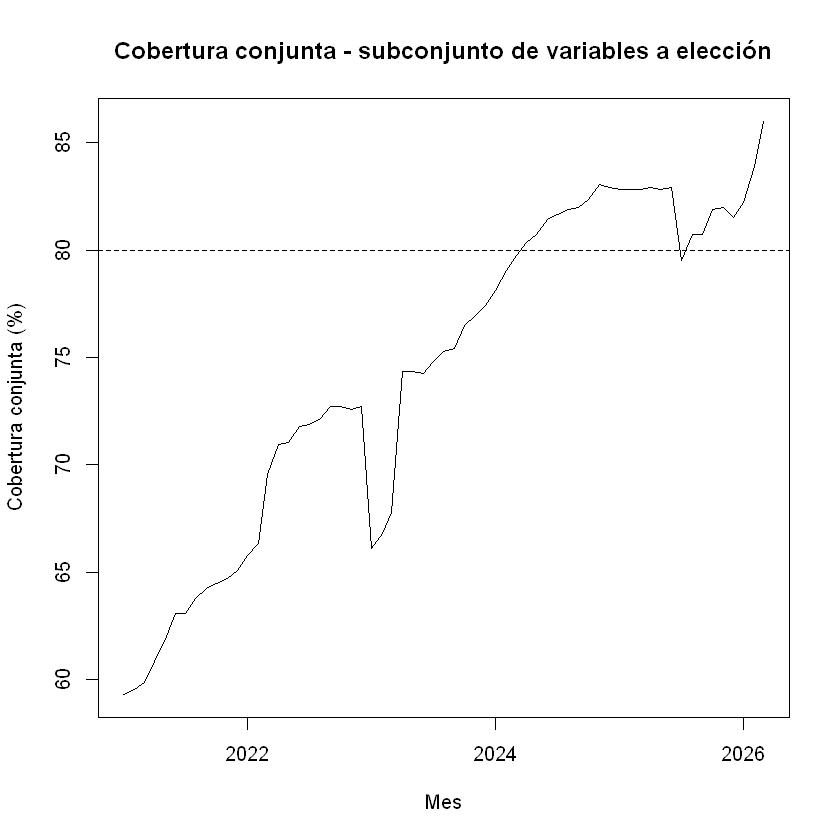

In [231]:
# ============================================================
# EXPLORACIÓN MANUAL: COBERTURA PARA UN SUBCONJUNTO DE VARIABLES
#
# Comentar/descomentar líneas de CUSTOM_VARIABLE_SET y volver a
# correr esta celda para ver cómo cambia la cobertura conjunta
# mes a mes con exactamente esas variables. Por ejemplo, para
# quedarse sólo con Spotify listeners e Instagram followers,
# dejar sin comentar únicamente esas dos líneas y comentar el
# resto.
#
# custom_joint_coverage$joint_coverage_pct es el % de artistas
# que tienen TODAS las variables no comentadas presentes ese
# mes (misma lógica que build_joint_completeness /
# VARIABLE_SET_CANDIDATES más arriba, para un conjunto elegido
# a mano en vez de uno predefinido).
# ============================================================

CUSTOM_VARIABLE_SET <- c(

  # # --- Fan Stats ---
   "fan_stats__spotify__followers",
  # "fan_stats__spotify__listeners",
  # "fan_stats__twitter__followers",
  # "fan_stats__youtube_channel__subscribers",
   "fan_stats__youtube_channel__views",
  # "fan_stats__youtube_artist__monthly_views",
  "fan_stats__instagram__followers"
   #,
  # "fan_stats__tiktok__followers",
  # "fan_stats__tiktok__likes",

  # # --- Playlist Evolution ---
  # "playlist_evolution__spotify__playlist_count",
  # "playlist_evolution__spotify__ed_playlist_count",
  # "playlist_evolution__spotify__playlist_total_reach",
  # "playlist_evolution__spotify__ed_playlist_total_reach",
  # "playlist_evolution__youtube__playlist_count",
  # "playlist_evolution__youtube__ed_playlist_count",
  # "playlist_evolution__youtube__playlist_total_reach",
  # "playlist_evolution__youtube__ed_playlist_total_reach",
  # "playlist_evolution__amazon__playlist_count",
  # "playlist_evolution__amazon__ed_playlist_count"
)

stopifnot(
  "CUSTOM_VARIABLE_SET tiene nombres fuera de REQUIRED_VARIABLES: revisar typos/comentarios" =
    all(CUSTOM_VARIABLE_SET %in% REQUIRED_VARIABLES),
  "CUSTOM_VARIABLE_SET quedó vacío: descomentar al menos una variable" =
    length(CUSTOM_VARIABLE_SET) > 0
)

custom_joint_coverage <- build_joint_completeness(
  monthly = pilot2_monthly,
  ids = PILOT2_ARTIST_IDS,
  variables = CUSTOM_VARIABLE_SET,
  since = FAN_SINCE,
  until = END_DATE
)

cat(
  "Variables incluidas (", length(CUSTOM_VARIABLE_SET), "):\n",
  paste(CUSTOM_VARIABLE_SET, collapse = ", "),
  "\n\n",
  sep = ""
)

custom_joint_coverage[
  ,
  .(
    primer_mes = min(month),
    ultimo_mes = max(month),
    cobertura_minima = min(joint_coverage_pct),
    cobertura_mediana = median(joint_coverage_pct),
    cobertura_maxima = max(joint_coverage_pct)
  )
]

plot(
  custom_joint_coverage$month,
  custom_joint_coverage$joint_coverage_pct,
  type = "l",
  xlab = "Mes",
  ylab = "Cobertura conjunta (%)",
  main = "Cobertura conjunta - subconjunto de variables a elección"
)

abline(
  h = COVERAGE_THRESHOLD,
  lty = 2
)

custom_joint_coverage
